In [1]:
import pandas as pd
import re
from difflib import get_close_matches
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.cross_decomposition import PLSRegression
from sklearn.feature_selection import VarianceThreshold
import numpy as np
from pathlib import Path
from statsmodels.formula.api import ols
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
from scipy.stats import f_oneway
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram
from scipy.stats import chi2_contingency
from pathlib import Path
import statsmodels.api as sm
from scipy import stats
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, StratifiedKFold, cross_validate
from sklearn.linear_model import RidgeCV, ElasticNetCV, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, accuracy_score, f1_score,calinski_harabasz_score,davies_bouldin_score
from scipy.cluster.hierarchy import linkage, fcluster, cophenet
from scipy.spatial.distance import pdist
from joblib import Parallel, delayed
import io, base64
from scipy.stats import kruskal
from IPython.display import HTML, display
from sklearn.multioutput import MultiOutputRegressor
from sklearn.impute import SimpleImputer
from sklearn.decomposition import IncrementalPCA 
from sklearn.cluster import AgglomerativeClustering
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
!pip install imblearn
from sklearn.ensemble import GradientBoostingClassifier
!pip install xgboost
from imblearn.over_sampling import ADASYN
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import make_scorer, r2_score, mean_squared_error
from xgboost import XGBRegressor
!pip install shap
from statsmodels.stats.multitest import multipletests
from scipy.stats import t as tdist
from sklearn.svm import SVR
import shap
from sklearn.model_selection import GridSearchCV, train_test_split
from xgboost import XGBRegressor
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import r2_score, make_scorer
from sklearn.ensemble import StackingRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_predict
from sklearn.feature_selection import f_regression
from scipy.stats import f
from statsmodels.stats.multitest import multipletests
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import RidgeCV, MultiTaskElasticNetCV
from sklearn.model_selection import cross_val_score, KFold
from sklearn.pipeline import Pipeline
from sklearn.cross_decomposition import PLSRegression
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import RidgeCV, MultiTaskElasticNetCV
from sklearn.cross_decomposition import PLSRegression
from sklearn.kernel_ridge import KernelRidge
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from joblib import Parallel, delayed
from scipy.stats import t
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram


In [2]:
# Read the genetic data
genetic_data = pd.read_csv(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\GeneMarkers-95 varieties 1.csv")

genetic_data.head()

,taglo_id,ATLANTIC_124776,ESCORT_159228,ARGOS_120931,ALTURAS_329540,ELMUNDO_835520,NADINE_241950,VIOLETQUEEN_3345402,DEODARA_513721,MEMPHIS_2279529,...,DIAMANT_153502,INNOVATOR_234757,TRIPLE7_3347283,SPUNTA_283648,ANTI_118190,CARRERA_142554,FORTUS_3279866,SMART_1883446,SALINERO_253609,FABULA_171173
0,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,10,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,13,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,17,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,21,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
aroma_df= pd.read_csv( r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Documents\GitHub\internship\mixed biorep\aroma_intensity_matrix.csv")

aroma_df.head(20)

,Variety,1-Heptanol,1-Nonanol,1-Octen-3-ol,1-Phenylethanol,"2,3-Pentanedione","2,4-Decadienal","2,6-Dimethylpyrazine",2-Isopropyl-3-methoxypyrazine,2-Methyl-1-propanol,...,Methional,Methyl butanoate,Nonanal,Octanal,Octanoic acid,Pentanal,Phenylacetaldehyde,Propanal,Propanoic acid,Tetramethylpyrazine
0,ADORA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,1.850711e+07,4.261687e+06,1.214959e+06,NaN,333823.619898,NaN,NaN,NaN
1,AGRIA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,1.197010e+07,2.217862e+06,NaN,1.037236e+06,NaN,NaN,NaN,1.906090e+06
2,ALOUETTE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,5.473360e+05,1.221545e+07,1.900674e+06,NaN,NaN,NaN,NaN,NaN,NaN
3,ALTHEA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,3.992090e+06,2.439253e+07,NaN,NaN,1.778639e+06,NaN,NaN,NaN,NaN
4,ALTURAS,65076.30731,NaN,NaN,NaN,NaN,NaN,NaN,1.462283e+06,NaN,...,NaN,NaN,1.760424e+07,7.600043e+04,NaN,3.354290e+06,NaN,NaN,NaN,1.235767e+06
5,ALTUS,NaN,62183.035224,NaN,7743.480421,NaN,59501.906333,NaN,NaN,NaN,...,NaN,5.375849e+04,1.640739e+07,5.309598e+04,NaN,3.237747e+06,702264.693113,1.780537e+06,NaN,2.454963e+05
6,ALVERSTONE R.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,1.670279e+07,3.407231e+04,NaN,1.282714e+06,NaN,NaN,NaN,1.251715e+05
7,ANIVIA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,1.516246e+07,2.732010e+06,NaN,NaN,NaN,NaN,NaN,2.326265e+06
8,ANTI,NaN,12751.163170,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,1.717864e+07,3.129789e+04,NaN,NaN,NaN,NaN,NaN,2.527107e+05
9,ARDECHE,NaN,9212.434129,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,1.627534e+07,3.799721e+04,NaN,NaN,NaN,NaN,NaN,1.651753e+05


In [4]:
sensory_pcs = pd.read_csv(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep\sensory_pca_projection_knn_no_outlier_removal.csv")

In [5]:
import pandas as pd
import numpy as np
import re

# --- Helper functions ---
def to_numeric(df):
    out = df.copy()
    for c in out.columns:
        out[c] = pd.to_numeric(out[c], errors="coerce")
    return out

def norm_key(s):
    """Normalize variety names to a comparable key"""
    s = (str(s).upper().replace(".", "").replace(" ", ""))
    s = re.sub(r'\bR\b', '', s)
    s = re.sub(r'RUSSET', '', s)
    return s.split("_")[0]


# --- Genetic data ---
mrk_col = "TAGLO_ID" if "TAGLO_ID" in genetic_data.columns else genetic_data.columns[0]

G = (
    genetic_data.dropna(subset=[mrk_col])
    .drop_duplicates(subset=[mrk_col])
    .set_index(mrk_col)
)

G = to_numeric(G)
gd = G.T
gd.index.name = "Variety_raw"
gd.index = gd.index.map(norm_key)

# Collapse duplicates (if multiple rows per variety)
gd = gd.groupby(gd.index, observed=True).mean()
gd.columns = ["GEN__" + str(c) for c in gd.columns]
print(f"Genetic table after reshape: {gd.shape}")


# --- Aroma data ---
af = aroma_df.copy()
assert "Variety" in af.columns, "aroma_df must have a 'Variety' column"
af["__key__"] = af["Variety"].map(norm_key)
af = af.set_index("__key__")

aroma_cols = [c for c in af.columns if c not in ["Variety", "index"]]
A_raw = to_numeric(af[aroma_cols])

# --- Filtering aroma data ---
n_before = len(A_raw.columns)

# Drop only columns that are completely NaN
dropped_allnan = [c for c in A_raw.columns if A_raw[c].isna().all()]
A_step1 = A_raw.drop(columns=dropped_allnan)

#  Keep all remaining columns (no <20% filtering)
A = A_step1.fillna(0)

# Remove constant columns
A = A.loc[:, A.std(ddof=0) > 0]

print(f"\n# Aroma data cleanup summary:")
print(f"  Total columns before: {n_before}")
print(f"  Dropped (all NaN): {len(dropped_allnan)}")
print(f"  Dropped (<20% valid values): 0 (disabled)")
print(f"  Final usable aroma columns: {A.shape[1]}")
print("  Sample aroma cols:", list(A.columns[:8]))


# --- Sensory PCs ---
assert "Variety" in sensory_pcs.columns, "sensory_pca_projection_knn_clean.csv must have a 'Variety' column"

sensory_pcs["__key__"] = sensory_pcs["Variety"].map(norm_key)
sensory_pcs = sensory_pcs.set_index("__key__")

S = to_numeric(sensory_pcs.drop(columns=["Variety", "is_panel"], errors="ignore")).fillna(0)
S = S.loc[:, S.std(ddof=0) > 0]
print(f"\n# Sensory PCs: {S.shape[1]}")
print("Sample sensory cols:", list(S.columns[:8]))


# --- Merge tables ---
gk = gd.copy()
gk.index.name = "Variety"

merged_snp_aroma = gk.join(A, how="inner")
merged_snp_sensory = gk.join(S, how="inner")
merged_all = gk.join(pd.concat([A, S], axis=1), how="inner")

print(f"\nMerged shape (varieties × [SNPs + aroma]): {merged_snp_aroma.shape}")
print(f"Merged shape (varieties × [SNPs + sensory PCs]): {merged_snp_sensory.shape}")
print(f"Merged shape (varieties × [SNPs + aroma + sensory PCs]): {merged_all.shape}")


Genetic table after reshape: (94, 262434)

# Aroma data cleanup summary:
  Total columns before: 47
  Dropped (all NaN): 0
  Dropped (<20% valid values): 0 (disabled)
  Final usable aroma columns: 47
  Sample aroma cols: ['1-Heptanol', '1-Nonanol', '1-Octen-3-ol', '1-Phenylethanol', '2,3-Pentanedione', '2,4-Decadienal', '2,6-Dimethylpyrazine', '2-Isopropyl-3-methoxypyrazine']

# Sensory PCs: 3
Sample sensory cols: ['PC1', 'PC2', 'PC3']

Merged shape (varieties × [SNPs + aroma]): (94, 262481)
Merged shape (varieties × [SNPs + sensory PCs]): (94, 262437)
Merged shape (varieties × [SNPs + aroma + sensory PCs]): (94, 262484)


In [6]:
all_gwas_df= pd.read_csv(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep\gwas_aroma_all_traits.csv")

In [7]:
all_gwas_df_sensory= pd.read_csv(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep\gwas_sensory_PCs.csv")


[Modeling] Trait: 1-Heptanol

[Modeling] Trait: 1-Nonanol

[Modeling] Trait: 1-Octen-3-ol

[Modeling] Trait: 1-Phenylethanol

[Modeling] Trait: 2,3-Pentanedione

[Modeling] Trait: 2,4-Decadienal

[Modeling] Trait: 2,6-Dimethylpyrazine

[Modeling] Trait: 2-Isopropyl-3-methoxypyrazine

[Modeling] Trait: 2-Methyl-1-propanol

[Modeling] Trait: 2-Methylthiazole

[Modeling] Trait: 2-Nonanone

[Modeling] Trait: 2-Propanone, 1-methoxy-

[Modeling] Trait: 3-Heptanone

[Modeling] Trait: 3-Octanone

[Modeling] Trait: Acetic acid

[Modeling] Trait: Acetophenone

[Modeling] Trait: Benzaldehyde

[Modeling] Trait: Benzeneacetaldehyde

[Modeling] Trait: Benzyl alcohol

[Modeling] Trait: Butanal, 3-methyl-

[Modeling] Trait: Butanoic acid

[Modeling] Trait: Decanal

[Modeling] Trait: Dimethyl disulfide

[Modeling] Trait: Dimethyl trisulfide

[Modeling] Trait: Ethanol

[Modeling] Trait: Ethyl acetate

[Modeling] Trait: Ethyl hexanoate

[Modeling] Trait: Ethyl pentanoate

[Modeling] Trait: Ethyl propano

,Trait,n_SNPs,Best_alpha,Best_gamma,CV_Best_R2,R2_in_sample,MSE,RMSE,MAE
6,"2,6-Dimethylpyrazine",145,0.01,1.0000,0.788889,0.999901,1.317220e+03,3.629352e+01,3.743391e+00
8,2-Methyl-1-propanol,145,0.01,1.0000,0.788889,0.999901,1.421379e+05,3.770119e+02,3.888580e+01
22,Dimethyl disulfide,1,0.01,10.0000,0.788889,0.999901,8.165220e+04,2.857485e+02,2.947271e+01
35,Isovaleric acid,1,0.01,10.0000,0.788889,0.999901,6.621419e+04,2.573212e+02,2.654065e+01
28,Ethyl propanoate,145,0.01,1.0000,0.788889,0.999901,4.030993e+03,6.349011e+01,6.548504e+00
25,Ethyl acetate,145,0.01,1.0000,0.788889,0.999901,9.480983e+03,9.737034e+01,1.004298e+01
45,Propanoic acid,43,0.01,1.0000,0.788889,0.999901,4.393147e+04,2.095984e+02,2.161842e+01
33,Hexanol,95,0.01,0.0001,0.637457,0.876355,3.635568e+10,1.906717e+05,1.512117e+05
11,"2-Propanone, 1-methoxy-",249,0.01,0.0001,0.594622,0.964674,8.811276e+11,9.386840e+05,7.240189e+05
39,Nonanal,196,0.01,0.0001,0.592762,0.939281,1.579610e+12,1.256825e+06,1.004989e+06


C:\Users\fatemehm\AppData\Local\Temp\ipykernel_8976\4265463343.py:104: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


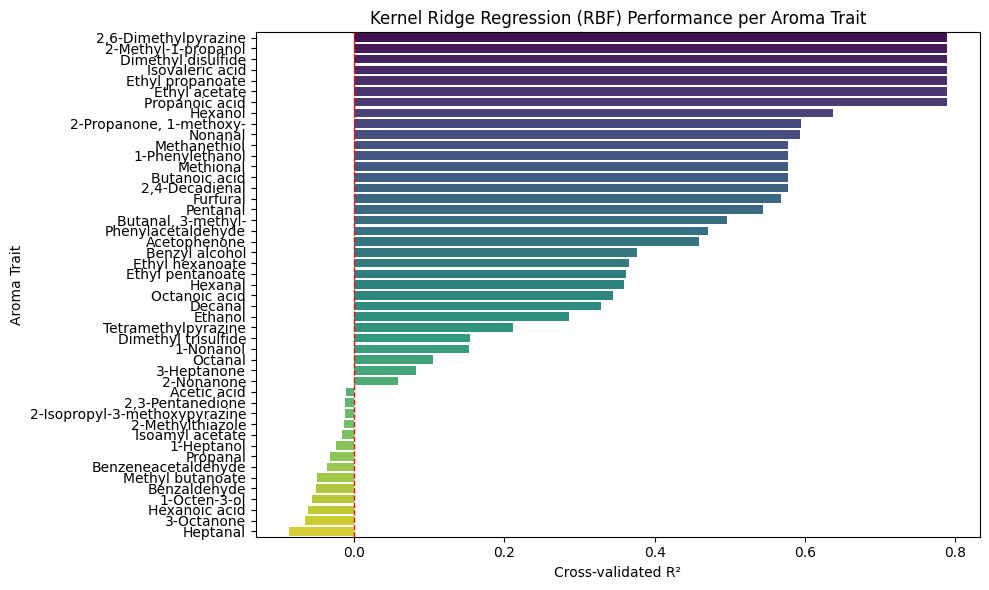

In [8]:

from sklearn.metrics import (
    make_scorer, r2_score, mean_squared_error,
    mean_absolute_error
)
#  Config

param_grid = {
    "alpha": [0.01, 0.1, 1, 10, 100, 1000],
    "gamma": [1e-4, 1e-3, 1e-2, 0.1, 1, 10]
}
cv = KFold(n_splits=5, shuffle=True, random_state=42)


#  Evaluation helper
def evaluate_regression(y_true, y_pred):
    return {
        "R2_in_sample": r2_score(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
    }


def ld_prune(X_df, threshold=0.9, max_snps=2000):
    """
    Perform LD pruning on SNP matrix.
    Removes SNPs that are highly correlated (|r| > threshold).
    """
    X_df = X_df.loc[:, X_df.std() > 0]
    if X_df.shape[1] > max_snps:
        X_df = X_df.iloc[:, :max_snps]
    if X_df.shape[1] <= 1:
        return X_df

    corr = X_df.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    to_drop = [col for col in upper.columns if any(upper[col] > threshold)]
    return X_df.drop(columns=to_drop)


#  Load GWAS results

gwas_all = pd.read_csv(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep\gwas_aroma_all_traits.csv")

results = []

# loop over traits
for trait in gwas_all["Trait"].unique():
    print(f"\n[Modeling] Trait: {trait}")
    gwas_df = gwas_all[gwas_all["Trait"] == trait]

    # pick top SNPs
    top_snps = gwas_df.sort_values("p_fdr").head(2000)["SNP"].tolist()
    if not top_snps:
        print("  No SNPs for modeling.")
        continue

    # SNP matrix
    X = merged_snp_aroma[top_snps].fillna(0).astype(float)
    X_pruned = ld_prune(X, threshold=0.95)

    if X_pruned.shape[1] == 0:
        print("  No SNPs after pruning.")
        continue

    # standardize + get target
    X_scaled = StandardScaler().fit_transform(X_pruned)
    y = merged_snp_aroma[trait].astype(float).values

    # grid search KRR
    grid = GridSearchCV(
        KernelRidge(kernel="rbf"),
        param_grid,
        cv=cv,
        scoring=make_scorer(r2_score),
        n_jobs=-1
    )
    grid.fit(X_scaled, y)

    # best model prediction
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_scaled)

    # evaluate
    metrics = evaluate_regression(y, y_pred)

    # append results (important!)
    results.append({
        "Trait": trait,
        "n_SNPs": X_pruned.shape[1],
        "Best_alpha": grid.best_params_["alpha"],
        "Best_gamma": grid.best_params_["gamma"],
        "CV_Best_R2": grid.best_score_,
        **metrics
    })


results_df = pd.DataFrame(results)
results_df.to_csv(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep\final_models_with_metrics_all_traits.csv", index=False)

print("\n Modeling results saved to final_models_with_metrics_all_traits.csv")
display(results_df.sort_values("CV_Best_R2", ascending=False).head(10))
plt.figure(figsize=(10,6))
sns.barplot(
    data=results_df.sort_values("CV_Best_R2", ascending=False),
    x="CV_Best_R2", y="Trait", palette="viridis"
)
plt.axvline(0, color="red", linestyle="--", lw=1)  # mark zero baseline
plt.xlabel("Cross-validated R²")
plt.ylabel("Aroma Trait")
plt.title("Kernel Ridge Regression (RBF) Performance per Aroma Trait")
plt.tight_layout()
plt.show()


# KRR+ removing outliers


[Modeling - KRR] Trait: 1-Heptanol

[Modeling - KRR] Trait: 1-Nonanol

[Modeling - KRR] Trait: 1-Octen-3-ol

[Modeling - KRR] Trait: 1-Phenylethanol

[Modeling - KRR] Trait: 2,3-Pentanedione

[Modeling - KRR] Trait: 2,4-Decadienal

[Modeling - KRR] Trait: 2,6-Dimethylpyrazine

[Modeling - KRR] Trait: 2-Isopropyl-3-methoxypyrazine

[Modeling - KRR] Trait: 2-Methyl-1-propanol

[Modeling - KRR] Trait: 2-Methylthiazole

[Modeling - KRR] Trait: 2-Nonanone

[Modeling - KRR] Trait: 2-Propanone, 1-methoxy-

[Modeling - KRR] Trait: 3-Heptanone

[Modeling - KRR] Trait: 3-Octanone

[Modeling - KRR] Trait: Acetic acid

[Modeling - KRR] Trait: Acetophenone

[Modeling - KRR] Trait: Benzaldehyde

[Modeling - KRR] Trait: Benzeneacetaldehyde

[Modeling - KRR] Trait: Benzyl alcohol

[Modeling - KRR] Trait: Butanal, 3-methyl-

[Modeling - KRR] Trait: Butanoic acid

[Modeling - KRR] Trait: Decanal

[Modeling - KRR] Trait: Dimethyl disulfide

[Modeling - KRR] Trait: Dimethyl trisulfide

[Modeling - KRR] T

,Trait,n_SNPs,Best_alpha,Best_gamma,CV_Best_R2,R2_in_sample,MSE,RMSE,MAE
45,Propanoic acid,40,0.01,1.0000,0.788889,0.999901,4.537976e+04,2.130253e+02,22.331116
22,Dimethyl disulfide,1,0.01,10.0000,0.788235,0.999901,8.434403e+04,2.904204e+02,30.444333
25,Ethyl acetate,135,0.01,1.0000,0.788235,0.999901,9.793543e+03,9.896233e+01,10.374071
28,Ethyl propanoate,135,0.01,1.0000,0.788235,0.999901,4.163883e+03,6.452816e+01,6.764389
6,"2,6-Dimethylpyrazine",135,0.01,1.0000,0.788235,0.999901,1.360645e+03,3.688692e+01,3.866800
8,2-Methyl-1-propanol,135,0.01,1.0000,0.788235,0.999901,1.468238e+05,3.831759e+02,40.167753
35,Isovaleric acid,1,0.01,10.0000,0.788235,0.999901,6.839708e+04,2.615284e+02,27.415621
39,Nonanal,199,0.01,0.0001,0.634307,0.937117,1.566546e+12,1.251617e+06,993341.828125
33,Hexanol,93,0.01,0.0001,0.626046,0.875357,3.672833e+10,1.916464e+05,152181.684523
11,"2-Propanone, 1-methoxy-",244,0.01,0.0001,0.578880,0.963261,9.319127e+11,9.653563e+05,752969.397215


C:\Users\fatemehm\AppData\Local\Temp\ipykernel_8976\1409635899.py:94: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


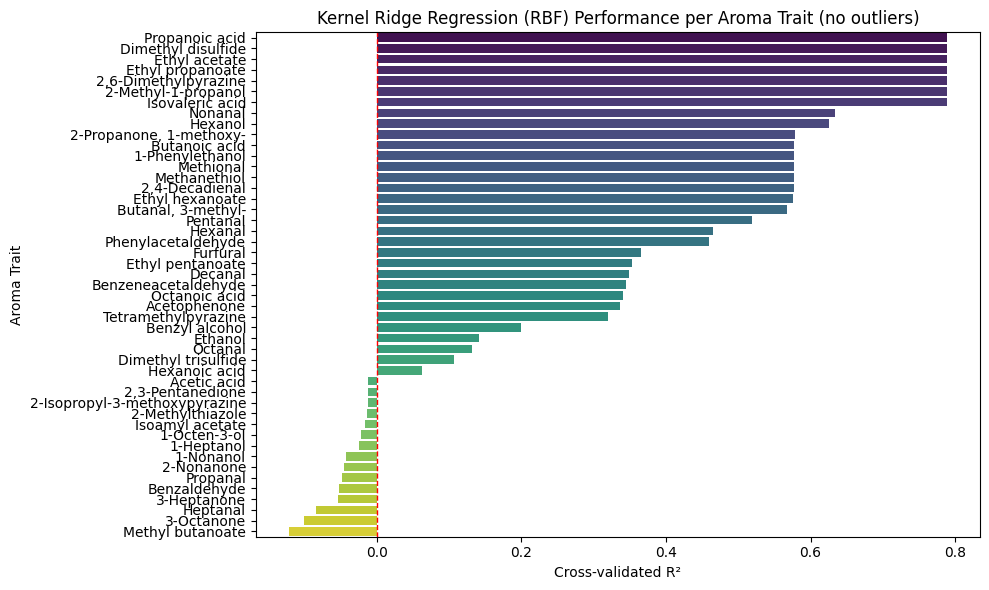

In [9]:

from sklearn.metrics import (
    make_scorer, r2_score, mean_squared_error,
    mean_absolute_error
)

param_grid = {
    "alpha": [0.01, 0.1, 1, 10, 100, 1000],
    "gamma": [1e-4, 1e-3, 1e-2, 0.1, 1, 10]
}
cv = KFold(n_splits=5, shuffle=True, random_state=42)


# Evaluation helper

def evaluate_regression(y_true, y_pred):
    return {
        "R2_in_sample": r2_score(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
    }

#  Load GWAS results + remove outliers

gwas_all = pd.read_csv(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep\gwas_aroma_all_traits.csv")

# Remove outliers from merged dataset
outliers =['ARGOS', 'NADINE','OSPREY']
df_aroma = merged_snp_aroma.drop(index=[o for o in outliers if o in merged_snp_aroma.index])

results = []

# loop over traits
for trait in gwas_all["Trait"].unique():
    print(f"\n[Modeling - KRR] Trait: {trait}")
    gwas_df = gwas_all[gwas_all["Trait"] == trait]

    # pick top SNPs
    top_snps = gwas_df.sort_values("p_fdr").head(2000)["SNP"].tolist()
    if not top_snps:
        print("  No SNPs for modeling.")
        continue

    # SNP matrix (without outliers)
    X = df_aroma[top_snps].fillna(0).astype(float)
    X_pruned = ld_prune(X, threshold=0.95)

    if X_pruned.shape[1] == 0:
        print("  No SNPs after pruning.")
        continue

    # standardize + get target (without outliers)
    X_scaled = StandardScaler().fit_transform(X_pruned)
    y = df_aroma[trait].astype(float).values

    # grid search KRR
    grid = GridSearchCV(
        KernelRidge(kernel="rbf"),
        param_grid,
        cv=cv,
        scoring=make_scorer(r2_score),
        n_jobs=-1
    )
    grid.fit(X_scaled, y)

    # best model prediction
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_scaled)

    # evaluate
    metrics = evaluate_regression(y, y_pred)

    # append results
    results.append({
        "Trait": trait,
        "n_SNPs": X_pruned.shape[1],
        "Best_alpha": grid.best_params_["alpha"],
        "Best_gamma": grid.best_params_["gamma"],
        "CV_Best_R2": grid.best_score_,
        **metrics
    })


#  Save modeling results

results_df = pd.DataFrame(results)
results_df.to_csv("final_krr_metrics_no_outliers.csv", index=False)

print("\n KRR results saved to final_krr_metrics_no_outliers.csv")
display(results_df.sort_values("CV_Best_R2", ascending=False).head(10))


plt.figure(figsize=(10,6))
sns.barplot(
    data=results_df.sort_values("CV_Best_R2", ascending=False),
    x="CV_Best_R2", y="Trait", palette="viridis"
)
plt.axvline(0, color="red", linestyle="--", lw=1)  # mark zero baseline
plt.xlabel("Cross-validated R²")
plt.ylabel("Aroma Trait")
plt.title("Kernel Ridge Regression (RBF) Performance per Aroma Trait (no outliers)")
plt.tight_layout()
plt.show()



# Kernel Ridge Regression + Gwas per trait for sensory


[Modeling - KRR] Trait: 1-Heptanol

[Modeling - KRR] Trait: 1-Nonanol

[Modeling - KRR] Trait: 1-Octen-3-ol

[Modeling - KRR] Trait: 1-Phenylethanol

[Modeling - KRR] Trait: 2,3-Pentanedione

[Modeling - KRR] Trait: 2,4-Decadienal

[Modeling - KRR] Trait: 2,6-Dimethylpyrazine

[Modeling - KRR] Trait: 2-Isopropyl-3-methoxypyrazine

[Modeling - KRR] Trait: 2-Methyl-1-propanol

[Modeling - KRR] Trait: 2-Methylthiazole

[Modeling - KRR] Trait: 2-Nonanone

[Modeling - KRR] Trait: 2-Propanone, 1-methoxy-

[Modeling - KRR] Trait: 3-Heptanone

[Modeling - KRR] Trait: 3-Octanone

[Modeling - KRR] Trait: Acetic acid

[Modeling - KRR] Trait: Acetophenone

[Modeling - KRR] Trait: Benzaldehyde

[Modeling - KRR] Trait: Benzeneacetaldehyde

[Modeling - KRR] Trait: Benzyl alcohol

[Modeling - KRR] Trait: Butanal, 3-methyl-

[Modeling - KRR] Trait: Butanoic acid

[Modeling - KRR] Trait: Decanal

[Modeling - KRR] Trait: Dimethyl disulfide

[Modeling - KRR] Trait: Dimethyl trisulfide

[Modeling - KRR] T

,Trait,n_SNPs,Best_alpha,Best_gamma,CV_Best_R2,R2_in_sample,MSE,RMSE,MAE
45,Propanoic acid,40,0.01,1.0000,0.788889,0.999901,4.537976e+04,2.130253e+02,22.331116
22,Dimethyl disulfide,1,0.01,10.0000,0.788235,0.999901,8.434403e+04,2.904204e+02,30.444333
25,Ethyl acetate,135,0.01,1.0000,0.788235,0.999901,9.793543e+03,9.896233e+01,10.374071
28,Ethyl propanoate,135,0.01,1.0000,0.788235,0.999901,4.163883e+03,6.452816e+01,6.764389
6,"2,6-Dimethylpyrazine",135,0.01,1.0000,0.788235,0.999901,1.360645e+03,3.688692e+01,3.866800
8,2-Methyl-1-propanol,135,0.01,1.0000,0.788235,0.999901,1.468238e+05,3.831759e+02,40.167753
35,Isovaleric acid,1,0.01,10.0000,0.788235,0.999901,6.839708e+04,2.615284e+02,27.415621
39,Nonanal,199,0.01,0.0001,0.634307,0.937117,1.566546e+12,1.251617e+06,993341.828125
33,Hexanol,93,0.01,0.0001,0.626046,0.875357,3.672833e+10,1.916464e+05,152181.684523
11,"2-Propanone, 1-methoxy-",244,0.01,0.0001,0.578880,0.963261,9.319127e+11,9.653563e+05,752969.397215


C:\Users\fatemehm\AppData\Local\Temp\ipykernel_8976\2168989572.py:94: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


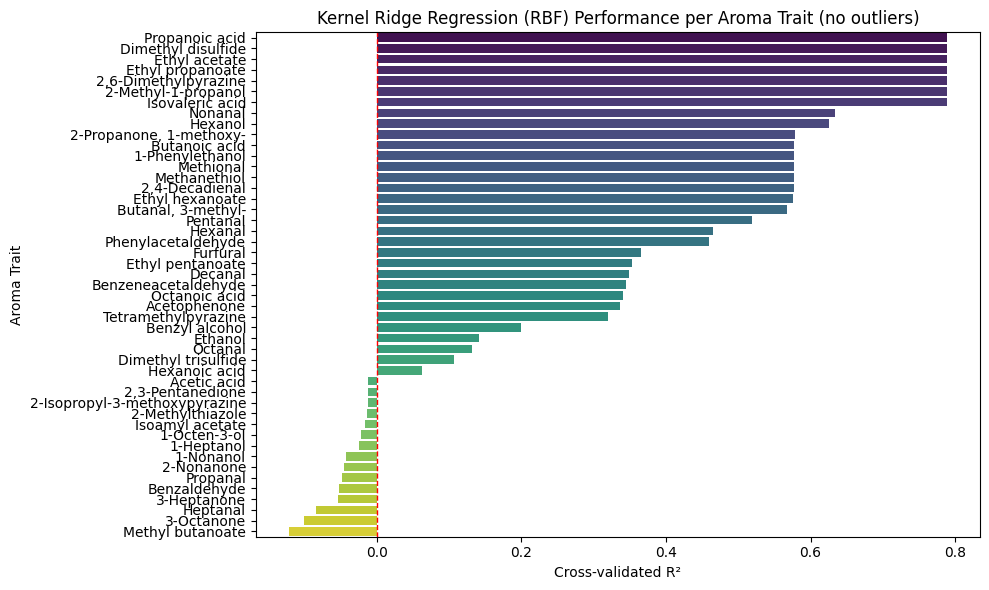

In [10]:

from sklearn.metrics import (
    make_scorer, r2_score, mean_squared_error,
    mean_absolute_error
)

param_grid = {
    "alpha": [0.01, 0.1, 1, 10, 100, 1000],
    "gamma": [1e-4, 1e-3, 1e-2, 0.1, 1, 10]
}
cv = KFold(n_splits=5, shuffle=True, random_state=42)


# Evaluation helper

def evaluate_regression(y_true, y_pred):
    return {
        "R2_in_sample": r2_score(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
    }

#  Load GWAS results + remove outliers

gwas_all = pd.read_csv(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep\gwas_aroma_all_traits.csv")

# Remove outliers from merged dataset
outliers =['ARGOS','NADINE','OSPREY']
df_aroma = merged_snp_aroma.drop(index=[o for o in outliers if o in merged_snp_aroma.index])

results = []

# loop over traits
for trait in gwas_all["Trait"].unique():
    print(f"\n[Modeling - KRR] Trait: {trait}")
    gwas_df = gwas_all[gwas_all["Trait"] == trait]

    # pick top SNPs
    top_snps = gwas_df.sort_values("p_fdr").head(2000)["SNP"].tolist()
    if not top_snps:
        print("  No SNPs for modeling.")
        continue

    # SNP matrix (without outliers)
    X = df_aroma[top_snps].fillna(0).astype(float)
    X_pruned = ld_prune(X, threshold=0.95)

    if X_pruned.shape[1] == 0:
        print("  No SNPs after pruning.")
        continue

    # standardize + get target (without outliers)
    X_scaled = StandardScaler().fit_transform(X_pruned)
    y = df_aroma[trait].astype(float).values

    # grid search KRR
    grid = GridSearchCV(
        KernelRidge(kernel="rbf"),
        param_grid,
        cv=cv,
        scoring=make_scorer(r2_score),
        n_jobs=-1
    )
    grid.fit(X_scaled, y)

    # best model prediction
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_scaled)

    # evaluate
    metrics = evaluate_regression(y, y_pred)

    # append results
    results.append({
        "Trait": trait,
        "n_SNPs": X_pruned.shape[1],
        "Best_alpha": grid.best_params_["alpha"],
        "Best_gamma": grid.best_params_["gamma"],
        "CV_Best_R2": grid.best_score_,
        **metrics
    })


#  Save modeling results

results_df = pd.DataFrame(results)
results_df.to_csv("final_krr_metrics_no_outliers.csv", index=False)

print("\n KRR results saved to final_krr_metrics_no_outliers.csv")
display(results_df.sort_values("CV_Best_R2", ascending=False).head(10))


plt.figure(figsize=(10,6))
sns.barplot(
    data=results_df.sort_values("CV_Best_R2", ascending=False),
    x="CV_Best_R2", y="Trait", palette="viridis"
)
plt.axvline(0, color="red", linestyle="--", lw=1)  # mark zero baseline
plt.xlabel("Cross-validated R²")
plt.ylabel("Aroma Trait")
plt.title("Kernel Ridge Regression (RBF) Performance per Aroma Trait (no outliers)")
plt.tight_layout()
plt.show()



In [11]:

gwas_sensory = pd.read_csv(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep\gwas_sensory_PCs.csv")

param_grid = {
    "alpha": [0.01, 0.1, 1, 10, 100],
    "gamma": [1e-4, 1e-3, 1e-2, 0.1, 1]
}

results_krr = []

for trait in gwas_sensory["Trait"].unique():
    print(f"\n[KRR] Trait: {trait}")
    gwas_df = gwas_sensory[gwas_sensory["Trait"] == trait]

    top_snps = gwas_df.sort_values("p_fdr").head(1500)["SNP"].tolist()
    if not top_snps:
        continue

    X = merged_snp_sensory[top_snps].fillna(0).astype(float)
    X_pruned = ld_prune(X, threshold=0.95)

    if X_pruned.shape[1] == 0:
        continue

    X_scaled = StandardScaler().fit_transform(X_pruned)
    y = merged_snp_sensory[trait].astype(float).values

    grid = GridSearchCV(
        KernelRidge(kernel="rbf"),
        param_grid=param_grid,
        cv=3,
        scoring="r2",
        n_jobs=-1
    )
    grid.fit(X_scaled, y)

    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_scaled)

    metrics = evaluate_regression(y, y_pred)

    results_krr.append({
        "Trait": trait,
        "Model": "KernelRidge",
        "n_SNPs": X_pruned.shape[1],
        "Best_alpha": grid.best_params_["alpha"],
        "Best_gamma": grid.best_params_["gamma"],
        "CV_Best_R2": grid.best_score_,
        **metrics
    })

# Save results
results_df_krr = pd.DataFrame(results_krr)
results_df_krr.to_csv(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep\krr_models_sensory_PCs.csv", index=False)
print("\n KRR results saved to krr_models_sensory_PCs.csv")
display(results_df_krr.sort_values("CV_Best_R2", ascending=False).head(10))



[KRR] Trait: PC1

[KRR] Trait: PC2

[KRR] Trait: PC3

 KRR results saved to krr_models_sensory_PCs.csv


,Trait,Model,n_SNPs,Best_alpha,Best_gamma,CV_Best_R2,R2_in_sample,MSE,RMSE,MAE
0,PC1,KernelRidge,309,0.10,0.0001,0.582016,0.821641,0.729196,0.853930,0.671256
1,PC2,KernelRidge,114,0.01,0.0001,0.544616,0.883051,0.299735,0.547481,0.410872
2,PC3,KernelRidge,202,0.01,0.0001,0.512676,0.949781,0.043163,0.207757,0.164878


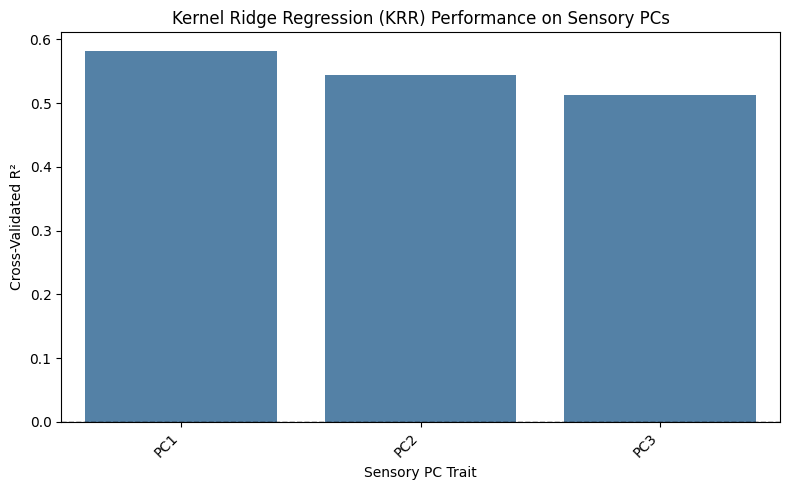

In [12]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=results_df_krr,
    x="Trait",
    y="CV_Best_R2",
    color="steelblue"
)

plt.xticks(rotation=45, ha="right")
plt.title("Kernel Ridge Regression (KRR) Performance on Sensory PCs")
plt.ylabel("Cross-Validated R²")
plt.xlabel("Sensory PC Trait")
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.tight_layout()
plt.show()

In [13]:
# Remove outliers
outliers = [ 'NADINE']
df_sensory_no_outliers = merged_snp_sensory.drop(index=[o for o in outliers if o in merged_snp_sensory.index])



[KRR] Trait: PC1

[KRR] Trait: PC2

[KRR] Trait: PC3


,Trait,Model,n_SNPs,Best_alpha,Best_gamma,CV_Best_R2,R2_in_sample,MSE,RMSE,MAE
0,PC1,KRR,309,0.01,0.001,0.613436,0.999322,0.002763,0.052569,0.041578
1,PC2,KRR,113,0.10,0.001,0.532066,0.892760,0.270181,0.519789,0.392075
2,PC3,KRR,200,0.10,0.001,0.473102,0.953081,0.040639,0.201590,0.164878


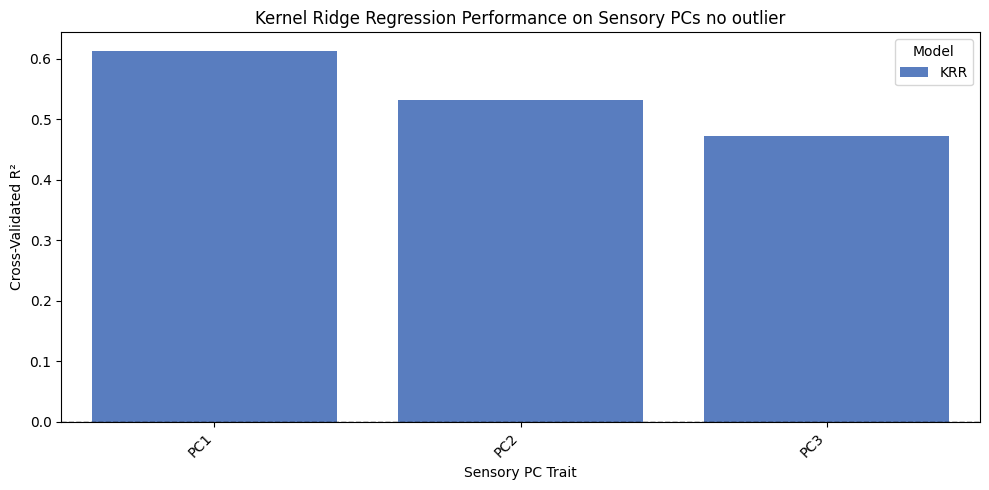

In [14]:
param_grid = {
    "alpha": [0.01, 0.1, 1, 10],
    "gamma": [1e-3, 1e-2, 0.1, 1]
}

results_krr = []

for trait in gwas_sensory["Trait"].unique():
    print(f"\n[KRR] Trait: {trait}")
    gwas_df = gwas_sensory[gwas_sensory["Trait"] == trait]
    top_snps = gwas_df.sort_values("p_fdr").head(1500)["SNP"].tolist()
    if not top_snps:
        continue

    X = df_sensory_no_outliers[top_snps].fillna(0).astype(float)
    X_pruned = ld_prune(X, threshold=0.95)
    if X_pruned.shape[1] == 0:
        continue

    X_scaled = StandardScaler().fit_transform(X_pruned)
    y = df_sensory_no_outliers[trait].astype(float).values

    grid = GridSearchCV(
        KernelRidge(kernel="rbf"),
        param_grid,
        cv=cv,
        scoring="r2",
        n_jobs=-1
    )
    grid.fit(X_scaled, y)

    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_scaled)
    metrics = evaluate_regression(y, y_pred)

    results_krr.append({
        "Trait": trait,
        "Model": "KRR",
        "n_SNPs": X_pruned.shape[1],
        "Best_alpha": grid.best_params_["alpha"],
        "Best_gamma": grid.best_params_["gamma"],
        "CV_Best_R2": grid.best_score_,
        **metrics
    })

results_df_krr_no_outliers = pd.DataFrame(results_krr)
results_df_krr_no_outliers.to_csv(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep\krr_models_sensory_PCs_no_outliers.csv", index=False)
display(results_df_krr_no_outliers.sort_values("CV_Best_R2", ascending=False).head(10))

# Visualization for KRR
plt.figure(figsize=(10, 5))
sns.barplot(
    data=results_df_krr_no_outliers,
    x="Trait",
    y="CV_Best_R2",
    hue="Model",   # though here it's only "KernelRidge"
    palette="muted"
)

plt.xticks(rotation=45, ha="right")
plt.title("Kernel Ridge Regression Performance on Sensory PCs no outlier")
plt.ylabel("Cross-Validated R²")
plt.xlabel("Sensory PC Trait")
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.legend(title="Model")
plt.tight_layout()
plt.show()



✅ Finished generating gene-based compound predictions.
Shape of predictions: (91, 47)
Common samples found: 91

High-performing predicted compounds: 18
→ ['1-Phenylethanol', '2,4-Decadienal', '2,6-Dimethylpyrazine', '2-Methyl-1-propanol', '2-Propanone, 1-methoxy-', 'Butanal, 3-methyl-', 'Butanoic acid', 'Dimethyl disulfide', 'Ethyl acetate', 'Ethyl hexanoate', 'Ethyl propanoate', 'Hexanol', 'Isovaleric acid', 'Methanethiol', 'Methional', 'Nonanal', 'Pentanal', 'Propanoic acid']

Valid predicted traits for correlation: 18
Valid sensory PCs for correlation: 3

💾 Correlation matrix saved as 'gene_predicted_compound_sensory_correlations_filtered.csv'


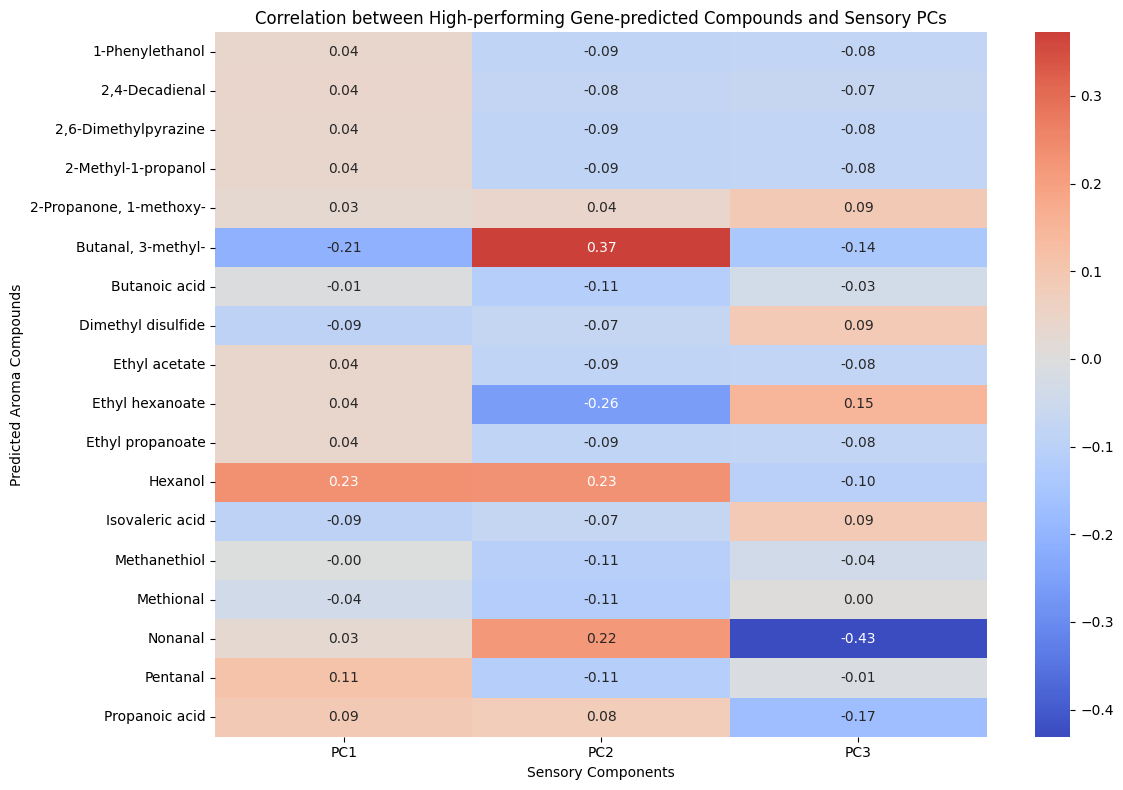


🔝 Top correlations between high-performing gene-predicted compounds and sensory components:


PC2  Butanal, 3-methyl-         0.372569
PC1  Hexanol                    0.232539
PC2  Hexanol                    0.229280
     Nonanal                    0.216335
PC3  Ethyl hexanoate            0.148758
PC1  Pentanal                   0.114084
     Propanoic acid             0.092620
PC3  2-Propanone, 1-methoxy-    0.091441
     Isovaleric acid            0.088906
     Dimethyl disulfide         0.088906
PC2  Propanoic acid             0.079398
PC1  2,4-Decadienal             0.041658
PC2  2-Propanone, 1-methoxy-    0.041030
PC1  Ethyl hexanoate            0.037994
     1-Phenylethanol            0.037417
     Ethyl acetate              0.037176
     Ethyl propanoate           0.037176
     2-Methyl-1-propanol        0.037176
     2,6-Dimethylpyrazine       0.037176
     Nonanal                    0.028098
dtype: float64

In [15]:
# ==========================================================
#  Correlation between High-performing Gene-predicted Compounds and Sensory PCs
# ==========================================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.kernel_ridge import KernelRidge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import make_scorer, r2_score

# ----------------------------------------------------------
# Step 1 — Load data
# ----------------------------------------------------------

gwas_all = pd.read_csv(
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep\gwas_aroma_all_traits.csv"
)

# ----------------------------------------------------------
# Step 2 — Generate gene-based predictions per aroma trait
# ----------------------------------------------------------

predictions = pd.DataFrame(index=df_aroma.index)

for trait in gwas_all["Trait"].unique():
    gwas_df = gwas_all[gwas_all["Trait"] == trait]
    top_snps = gwas_df.sort_values("p_fdr").head(2000)["SNP"].tolist()
    if not top_snps:
        continue

    X = df_aroma[top_snps].fillna(0).astype(float)
    X_pruned = ld_prune(X, threshold=0.95)
    if X_pruned.shape[1] == 0:
        continue

    X_scaled = StandardScaler().fit_transform(X_pruned)
    y = df_aroma[trait].astype(float).values

    param_grid = {
        "alpha": [0.01, 0.1, 1, 10, 100, 1000],
        "gamma": [1e-4, 1e-3, 1e-2, 0.1, 1, 10]
    }
    cv = KFold(n_splits=5, shuffle=True, random_state=42)

    grid = GridSearchCV(
        KernelRidge(kernel="rbf"),
        param_grid,
        cv=cv,
        scoring=make_scorer(r2_score),
        n_jobs=-1
    )
    grid.fit(X_scaled, y)
    best_model = grid.best_estimator_

    predictions[trait] = best_model.predict(X_scaled)

print("\n✅ Finished generating gene-based compound predictions.")
print(f"Shape of predictions: {predictions.shape}")

# ----------------------------------------------------------
# Step 3 — Align sample identifiers
# ----------------------------------------------------------

def normalize_index(df):
    df.index = df.index.astype(str).str.upper().str.replace(" ", "")
    return df

df_aroma = normalize_index(df_aroma)
sensory_pcs = normalize_index(sensory_pcs)
predictions = normalize_index(predictions)

common_samples = predictions.index.intersection(sensory_pcs.index)
print(f"Common samples found: {len(common_samples)}")

# ----------------------------------------------------------
# Step 4 — Keep only high-performing compounds (CV R² ≥ 0.5)
# ----------------------------------------------------------

krr_results = pd.read_csv("final_krr_metrics_no_outliers.csv")
high_perf_traits = krr_results.query("CV_Best_R2 >= 0.5")["Trait"].tolist()
print(f"\nHigh-performing predicted compounds: {len(high_perf_traits)}")
print("→", high_perf_traits)

# ----------------------------------------------------------
# Step 5 — Merge filtered predictions with sensory PCs
# ----------------------------------------------------------

predictions_filtered = predictions[high_perf_traits]

merged_corr_df = pd.merge(
    predictions_filtered.loc[common_samples],
    sensory_pcs.loc[common_samples],
    left_index=True,
    right_index=True
)

# Keep only numeric columns (avoid non-numeric like Variety)
merged_numeric = merged_corr_df.select_dtypes(include=[np.number])

# Determine valid columns
valid_pred_cols = [c for c in high_perf_traits if c in merged_numeric.columns]
valid_sensory_cols = [c for c in sensory_pcs.columns if c in merged_numeric.columns]

print(f"\nValid predicted traits for correlation: {len(valid_pred_cols)}")
print(f"Valid sensory PCs for correlation: {len(valid_sensory_cols)}")

# ----------------------------------------------------------
# Step 6 — Compute correlation matrix
# ----------------------------------------------------------

corr_matrix = merged_numeric.corr().loc[valid_pred_cols, valid_sensory_cols]

# Save correlation table
corr_matrix.to_csv("gene_predicted_compound_sensory_correlations_filtered.csv")
print("\n💾 Correlation matrix saved as 'gene_predicted_compound_sensory_correlations_filtered.csv'")

# ----------------------------------------------------------
# Step 7 — Visualize heatmap
# ----------------------------------------------------------

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Correlation between High-performing Gene-predicted Compounds and Sensory PCs")
plt.xlabel("Sensory Components")
plt.ylabel("Predicted Aroma Compounds")
plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# Step 8 — Inspect strongest correlations
# ----------------------------------------------------------

corr_pairs = corr_matrix.unstack().sort_values(ascending=False)
print("\n🔝 Top correlations between high-performing gene-predicted compounds and sensory components:")
display(corr_pairs.head(20))


In [16]:

top_compounds = corr_matrix.abs().mean(axis=1).sort_values(ascending=False)
display(top_compounds.head(10))


Butanal, 3-methyl-    0.239601
Nonanal               0.225115
Hexanol               0.188107
Ethyl hexanoate       0.148369
Propanoic acid        0.115144
Isovaleric acid       0.084907
Dimethyl disulfide    0.084907
Pentanal              0.079474
Ethyl acetate         0.067782
Ethyl propanoate      0.067782
dtype: float64

In [17]:
top_snps = gwas_df.sort_values("p_fdr").head(2000)["SNP"].tolist()


In [18]:
# 
top_traits = top_compounds.head(5).index.tolist()

important_genes = (
    gwas_all[gwas_all["Trait"].isin(top_traits)]
    .sort_values("p_fdr")
    .groupby("Trait")["SNP"]
    .apply(lambda x: x.head(20).tolist())  # ۲۰ SNP برتر برای هر trait
)

for trait, genes in important_genes.items():
    print(f"\nTrait: {trait}")
    print("Top associated genes:", ", ".join(genes))



Trait: Butanal, 3-methyl-
Top associated genes: GEN__414978, GEN__446864, GEN__446970, GEN__325527, GEN__292996, GEN__454434, GEN__454433, GEN__454749, GEN__454800, GEN__420972, GEN__108183, GEN__108182, GEN__552080, GEN__550321, GEN__414829, GEN__420341, GEN__406634, GEN__32271, GEN__414826, GEN__449423

Trait: Ethyl hexanoate
Top associated genes: GEN__250758, GEN__176959, GEN__177042, GEN__177092, GEN__177172, GEN__198590, GEN__198719, GEN__198821, GEN__183798, GEN__176580, GEN__176247, GEN__176313, GEN__197480, GEN__197530, GEN__197923, GEN__188433, GEN__184609, GEN__183624, GEN__183661, GEN__183729

Trait: Hexanol
Top associated genes: GEN__552889, GEN__268788, GEN__268764, GEN__268711, GEN__268704, GEN__268630, GEN__268478, GEN__268431, GEN__268544, GEN__468645, GEN__62628, GEN__396833, GEN__266825, GEN__325595, GEN__465385, GEN__266921, GEN__198114, GEN__62664, GEN__534412, GEN__444629

Trait: Nonanal
Top associated genes: GEN__10632, GEN__116604, GEN__463316, GEN__116607, GEN_


Analyzing Butanal, 3-methyl-...


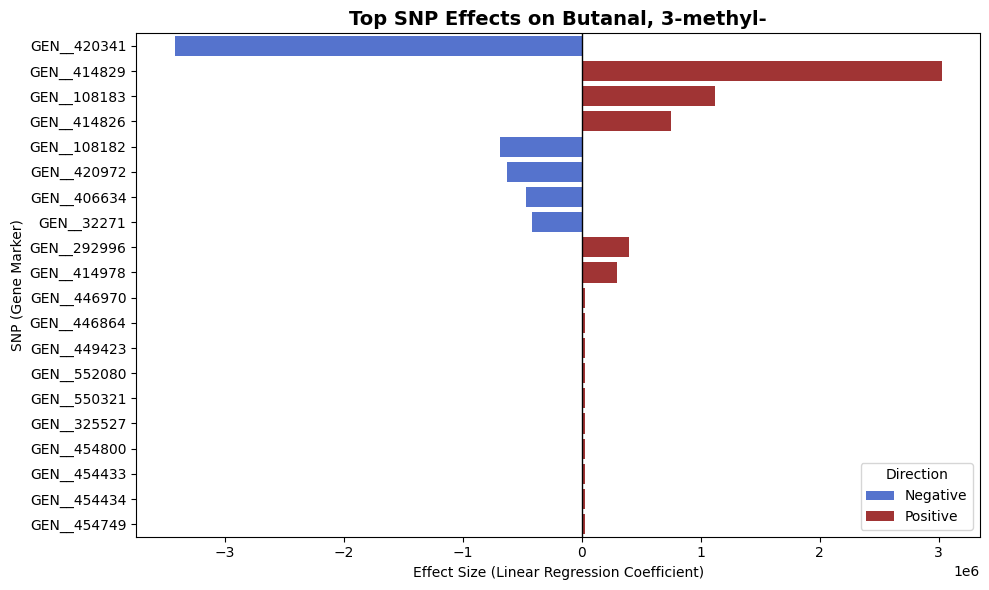


Analyzing Ethyl hexanoate...


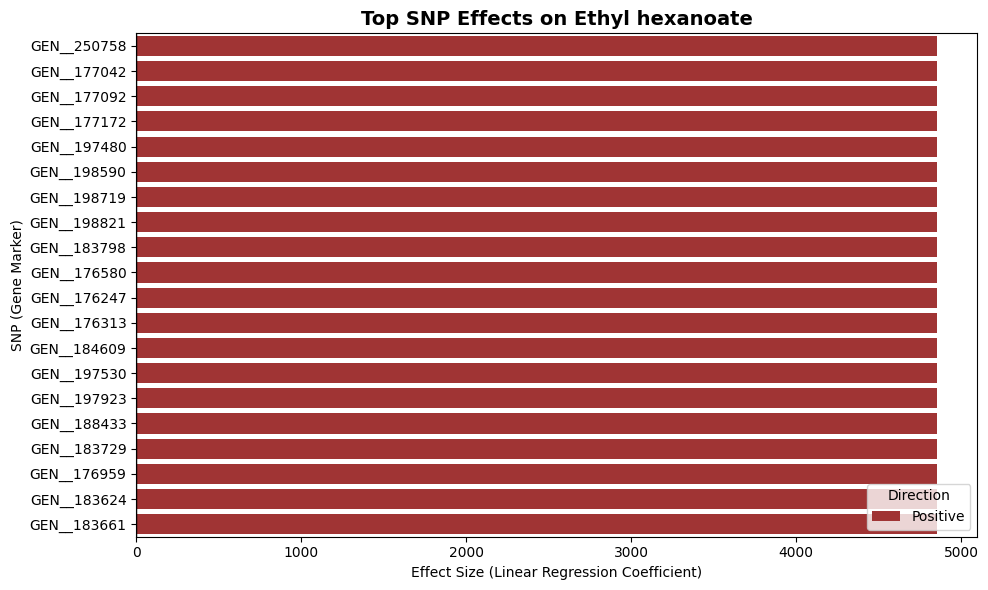


Analyzing Hexanol...


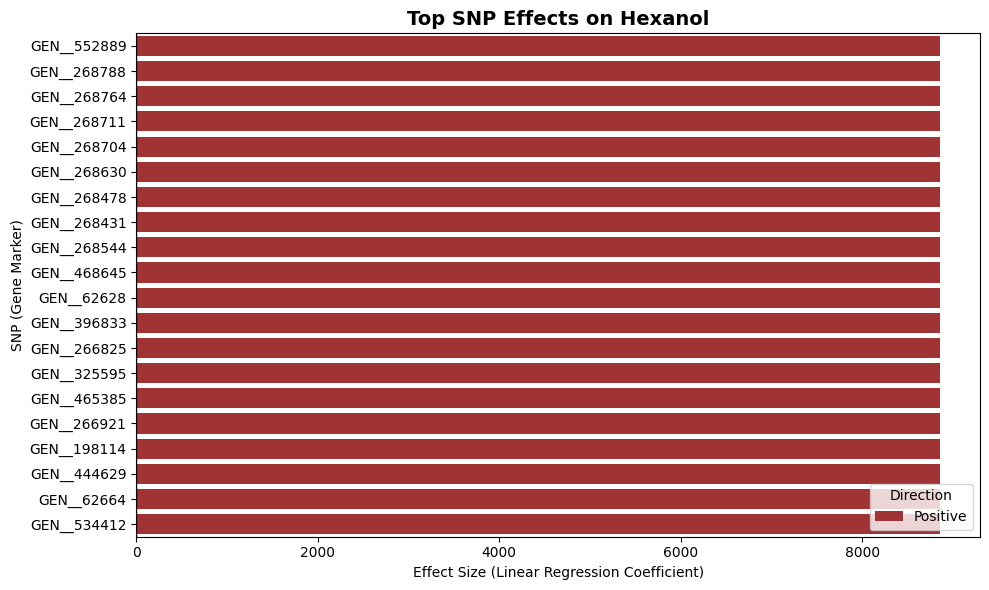


Analyzing Nonanal...


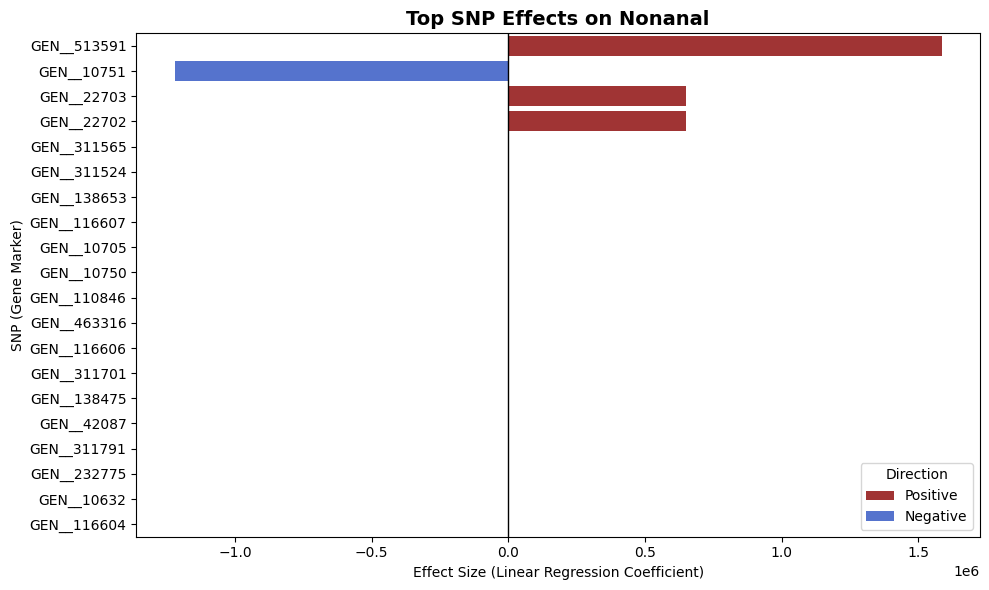


Analyzing Propanoic acid...


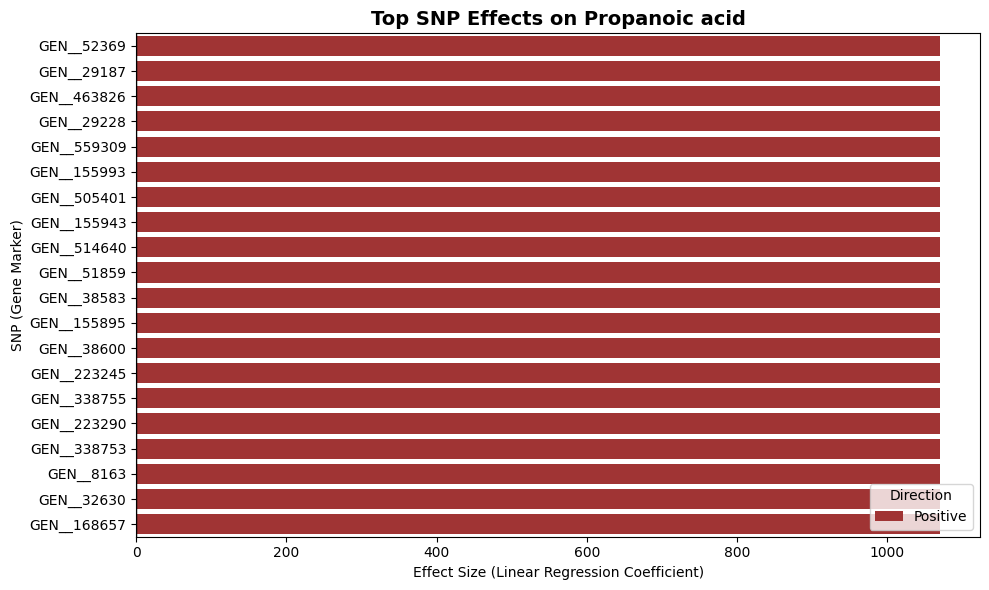

In [19]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# ==========================================================
# Define target aroma compounds
# ==========================================================
target_traits = ["Butanal, 3-methyl-", "Ethyl hexanoate", "Hexanol", "Nonanal", "Propanoic acid"]


# Loop through each compound
for trait in target_traits:
    if trait not in important_genes:
        print(f"⚠️ No GWAS data found for {trait}. Skipping.")
        continue

    print(f"\nAnalyzing {trait}...")

    # Get top SNPs for this aroma trait
    top_snps = important_genes[trait]

    # Prepare input matrices
    X = df_aroma[top_snps].fillna(0).astype(float)
    y = df_aroma[trait].astype(float).values

    # Scale features
    X_scaled = StandardScaler().fit_transform(X)

    # Fit linear regression model
    model = LinearRegression()
    model.fit(X_scaled, y)

    # Extract coefficients and direction
    coef_df = pd.DataFrame({
        "SNP": top_snps,
        "Effect": model.coef_,
        "Direction": ["Positive" if c > 0 else "Negative" for c in model.coef_]
    })
    coef_df["|Effect|"] = coef_df["Effect"].abs()
    coef_df = coef_df.sort_values("|Effect|", ascending=False).head(20)

    # ==========================================================
    # Plot effect direction for this trait
    # ==========================================================
    plt.figure(figsize=(10, 6))
    sns.barplot(
        x="Effect",
        y="SNP",
        data=coef_df,
        hue="Direction",
        palette={"Positive": "firebrick", "Negative": "royalblue"},
        dodge=False
    )
    plt.axvline(0, color="black", lw=1)
    plt.title(f"Top SNP Effects on {trait}", fontsize=14, weight="bold")
    plt.xlabel("Effect Size (Linear Regression Coefficient)")
    plt.ylabel("SNP (Gene Marker)")
    plt.legend(title="Direction", loc="lower right")
    plt.tight_layout()
    plt.show()


In [20]:
# # ==========================================================
# # PLS Regression — Linking Predicted Compounds to Sensory PCs
# # ==========================================================

# from sklearn.cross_decomposition import PLSRegression
# from sklearn.preprocessing import StandardScaler

# # ----------------------------------------------------------
# # 1 Prepare and standardize data
# # ----------------------------------------------------------
# X = predictions.loc[common_samples].copy()
# Y = sensory_pcs.loc[common_samples].copy()

# # Keep only numeric data
# X = X.select_dtypes(include=[np.number])
# Y = Y.select_dtypes(include=[np.number])

# # Standardize both sets
# X_scaled = StandardScaler().fit_transform(X)
# Y_scaled = StandardScaler().fit_transform(Y)

# # ----------------------------------------------------------
# # 2 Fit PLS model
# # ----------------------------------------------------------
# n_components = min(5, X_scaled.shape[1], Y_scaled.shape[1])  # safe upper bound
# pls = PLSRegression(n_components=n_components)
# pls.fit(X_scaled, Y_scaled)

# print(f"\n Fitted PLS model with {n_components} components")

# # ----------------------------------------------------------
# # 3️ Compute correlations between PLS components and sensory PCs
# # ----------------------------------------------------------
# pls_corr = pd.DataFrame(
#     np.corrcoef(pls.x_scores_.T, Y_scaled.T)[:n_components, n_components:],
#     index=[f"PLS{i+1}" for i in range(n_components)],
#     columns=Y.columns
# )

# print("\n Correlation between PLS components and sensory PCs:")
# display(pls_corr)

# # ----------------------------------------------------------
# #Plot correlation heatmap
# # ----------------------------------------------------------
# plt.figure(figsize=(8, 6))
# sns.heatmap(pls_corr, cmap="coolwarm", center=0, annot=True, fmt=".2f")
# plt.title("PLS Components vs Sensory PCs")
# plt.xlabel("Sensory PCs")
# plt.ylabel("PLS Components")
# plt.tight_layout()
# plt.show()

# # ----------------------------------------------------------
# # 5Analyze compound loadings (which compounds drive sensory variance)
# # ----------------------------------------------------------
# loadings_df = pd.DataFrame(
#     pls.x_loadings_,
#     index=X.columns,
#     columns=[f"PLS{i+1}" for i in range(n_components)]
# )

# # Save loadings
# loadings_path = r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Documents\GitHub\internship\mixed_biorep\pls_compound_loadings.csv"
# loadings_df.to_csv(loadings_path)
# print(f"\n Compound loadings saved to: {loadings_path}")

# # Visualize strongest contributors for the first component
# top_loadings = loadings_df["PLS1"].abs().sort_values(ascending=False).head(15)
# plt.figure(figsize=(8, 4))
# sns.barplot(x=top_loadings.values, y=top_loadings.index, palette="viridis")
# plt.title("Top 15 Compound Contributors to PLS1 (Sensory Dimension 1)")
# plt.xlabel("Absolute Loading Value")
# plt.ylabel("Compound")
# plt.tight_layout()
# plt.show()

# # ----------------------------------------------------------
# #  Save predicted sensory PCs based on gene-predicted compounds
# # ----------------------------------------------------------
# Y_pred = pls.predict(X_scaled)
# pls_pred_df = pd.DataFrame(Y_pred, index=X.index, columns=[f"Pred_{col}" for col in Y.columns])

# pls_pred_path = r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Documents\GitHub\internship\mixed_biorep\pls_predicted_sensory_PCs.csv"
# pls_pred_df.to_csv(pls_pred_path)
# print(f" PLS-predicted sensory PC scores saved to: {pls_pred_path}")


In [21]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt


# pls_loadings = pd.DataFrame(
#     pls.x_loadings_,
#     index=predictions.columns,  
#     columns=[f'PLS{i+1}' for i in range(pls.x_loadings_.shape[1])]
# )


# pls2_loadings = pls_loadings['PLS2'].abs().sort_values(ascending=False)


# top15_pls2 = pls2_loadings.head(15)


# plt.figure(figsize=(10,5))
# plt.barh(top15_pls2.index, top15_pls2.values, color=plt.cm.plasma(np.linspace(0,1,15)))
# plt.gca().invert_yaxis()
# plt.xlabel('Absolute Loading Value')
# plt.ylabel('Compound')
# plt.title('Top 15 Compound Contributors to PLS2 (Sensory Dimension 2)')
# plt.tight_layout()
# plt.show()

# # چاپ ترکیبات و مقادیر دقیق‌شان
# print("Top compounds driving PLS2:")
# display(pls_loadings.loc[top15_pls2.index, 'PLS2'])


In [22]:
# # ==========================================================
# #  PLS per Sensory PC — Chemically Classified and Sign-Aligned (Final Version)
# # ==========================================================

# import pandas as pd
# import numpy as np
# import seaborn as sns
# import matplotlib.pyplot as plt
# from sklearn.cross_decomposition import PLSRegression
# from sklearn.preprocessing import StandardScaler
# import os

# # ----------------------------------------------------------
# # Prepare and standardize data
# # ----------------------------------------------------------

# X = predictions.loc[common_samples].copy()
# Y = sensory_pcs.loc[common_samples].copy()

# # Keep only numeric data
# X = X.select_dtypes(include=[np.number])
# Y = Y.select_dtypes(include=[np.number])

# # Standardize predictors
# X_scaled = StandardScaler().fit_transform(X)

# # ----------------------------------------------------------
# # Define chemical classes
# # ----------------------------------------------------------

# compound_classes = {
#     # Ketones
#     "2,3-Pentanedione": "Ketone",
#     "3-Heptanone": "Ketone",
#     "2-Nonanone": "Ketone",

#     # Aldehydes
#     "Nonanal": "Aldehyde",
#     "Octanal": "Aldehyde",
#     "Decanal": "Aldehyde",
#     "2,4-Decadienal": "Aldehyde",
#     "Heptanal": "Aldehyde",
#     "Butanal, 3-methyl-": "Aldehyde",
#     "Methional": "Aldehyde",
#     "Phenylacetaldehyde": "Aldehyde",
#     "Benzaldehyde": "Aldehyde",

#     # Alcohols
#     "Hexanol": "Alcohol",
#     "1-Heptanol": "Alcohol",
#     "1-Nonanol": "Alcohol",
#     "Ethanol": "Alcohol",
#     "1-Octen-3-ol": "Alcohol",
#     "Benzyl alcohol": "Alcohol",
#     "1-Phenylethanol": "Alcohol",
#     "2-Methyl-1-propanol": "Alcohol",

#     # Esters
#     "Ethyl acetate": "Ester",
#     "Ethyl propanoate": "Ester",
#     "Ethyl hexanoate": "Ester",
#     "Methyl butanoate": "Ester",
#     "Isoamyl acetate": "Ester",

#     # Acids
#     "Acetic acid": "Acid",
#     "Isovaleric acid": "Acid",
#     "Butanoic acid": "Acid",
#     "Propanoic acid": "Acid",
#     "Hexanoic acid": "Acid",

#     # Sulfur compounds
#     "Methanethiol": "Sulfur",
#     "Dimethyl disulfide": "Sulfur",
#     "Dimethyl trisulfide": "Sulfur",
#     "2-Methylthiazole": "Sulfur",

#     # Pyrazines
#     "2,6-Dimethylpyrazine": "Pyrazine",
#     "2-Isopropyl-3-methoxypyrazine": "Pyrazine",

#     # Aromatics
#     "Furfural": "Aromatic",

#     # Default
#     "Other": "Other"
# }


# def classify(compound):
#     for key, cls in compound_classes.items():
#         if key.lower() in compound.lower():
#             return cls
#     return "Other"

# # ----------------------------------------------------------
# # Output folder
# # ----------------------------------------------------------

# base_dir = r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Documents\GitHub\internship\pls_classified"
# os.makedirs(base_dir, exist_ok=True)

# # ----------------------------------------------------------
# # Run PLS for each sensory PC
# # ----------------------------------------------------------

# for pc in Y.columns:
#     print(f"\n=== Running PLS for {pc} ===")
    
#     y = Y[[pc]].copy()
#     y_scaled = StandardScaler().fit_transform(y)

#     n_components = min(3, X_scaled.shape[1])
#     pls = PLSRegression(n_components=n_components)
#     pls.fit(X_scaled, y_scaled)

#     # ------------------------------------------------------
#     # Align all PLS components with sensory direction
#     # ------------------------------------------------------
#     corr = np.corrcoef(pls.x_scores_[:, 0].ravel(), y_scaled.ravel())[0, 1]

#     if corr < 0:
#         pls.x_loadings_ *= -1
#         pls.x_scores_ *= -1
#         pls.y_loadings_ *= -1
#         print(f" Flipped all PLS components for {pc} (positive = pleasant side)")
#     else:
#         print(f"→ PLS for {pc} already aligned (positive = pleasant side)")

#     # ------------------------------------------------------
#     # Create and save loadings table
#     # ------------------------------------------------------
#     loadings_df = pd.DataFrame(
#         pls.x_loadings_,
#         index=X.columns,
#         columns=[f"PLS{i+1}" for i in range(n_components)]
#     )
#     loadings_df["Class"] = loadings_df.index.map(classify)
#     load_path = os.path.join(base_dir, f"loadings_{pc}_aligned.csv")
#     loadings_df.to_csv(load_path)
#     print(f"→ Loadings saved: {load_path}")

#     # ------------------------------------------------------
#     # Diagnostic plot — score alignment check
#     # ------------------------------------------------------
#     plt.figure(figsize=(5, 4))
#     plt.scatter(pls.x_scores_[:, 0], y_scaled, c="steelblue", alpha=0.7)
#     plt.xlabel("PLS1 Score (compound axis)")
#     plt.ylabel(f"{pc} (Sensory PC, scaled)")
#     plt.title(f"Alignment check: {pc}")
#     plt.axhline(0, color="gray", linestyle="--")
#     plt.axvline(0, color="gray", linestyle="--")
#     plt.tight_layout()
#     plt.savefig(os.path.join(base_dir, f"alignment_check_{pc}.png"), dpi=300)
#     plt.show()

#     # ------------------------------------------------------
#     # Plot top 15 compound contributors for PLS1
#     # ------------------------------------------------------
#     top_loadings = loadings_df["PLS1"].sort_values(key=lambda x: np.abs(x), ascending=False).head(15)
#     top_df = loadings_df.loc[top_loadings.index].copy()
#     top_df["Compound"] = top_df.index
#     top_df["Loading"] = top_loadings.values

#     plt.figure(figsize=(9, 4))
#     sns.barplot(
#         data=top_df,
#         x="Loading",
#         y="Compound",
#         hue="Class",
#         dodge=False,
#         palette={
#             "Aldehyde": "#E69F00", "Alcohol": "#56B4E9", "Ketone": "#0072B2",
#             "Ester": "#CC79A7", "Acid": "#D55E00", "Sulfur": "#999933",
#             "Pyrazine": "#9966CC", "Aromatic": "#CC6666", "Other": "grey"
#         }
#     )
#     plt.axvline(0, color="black", linewidth=1)
#     plt.title(f"Top 15 Compound Contributors to PLS1 ({pc}) — Aligned with Sensory Direction")
#     plt.xlabel("PLS1 Loading (positive = same direction as sensory PC)")
#     plt.ylabel("Compound")
#     plt.tight_layout()
#     plt.legend(title="Chemical Class", bbox_to_anchor=(1.05, 1), loc="upper left")
#     plt.savefig(os.path.join(base_dir, f"pls1_{pc}_classified.png"), dpi=300, bbox_inches="tight")
#     plt.show()

# print("\n All PLS components processed, aligned, and classified.")


In [23]:
# # ==========================================================
# #  Compound-level correlation with sensory PCs (not grouped)
# # ==========================================================

# print("\n=== Compound-level correlations with sensory PCs ===")

# # Create a table to collect average correlations per compound
# compound_corrs = []

# for pc in Y.columns:
#     y = Y[[pc]].copy()
#     y_scaled = StandardScaler().fit_transform(y)

#     n_components = min(3, X_scaled.shape[1])
#     pls = PLSRegression(n_components=n_components)
#     pls.fit(X_scaled, y_scaled)

#     # Align direction with sensory side (same logic as before)
#     corr = np.corrcoef(pls.x_scores_[:, 0].ravel(), y_scaled.ravel())[0, 1]
#     if corr < 0:
#         pls.x_loadings_ *= -1
#         pls.x_scores_ *= -1
#         pls.y_loadings_ *= -1

#     loadings_df = pd.DataFrame(
#         pls.x_loadings_,
#         index=X.columns,
#         columns=[f"PLS{i+1}" for i in range(n_components)]
#     )

#     # Store correlation for PLS1 per compound (main sensory direction)
#     compound_corrs.append(loadings_df["PLS1"].rename(pc))

# # Combine across PCs
# compound_corrs_df = pd.concat(compound_corrs, axis=1)
# compound_corrs_df.columns = Y.columns

# # Save full compound–sensory matrix
# compound_corr_path = os.path.join(base_dir, "compound_vs_sensoryPC_PLS1.csv")
# compound_corrs_df.to_csv(compound_corr_path)
# print(f"→ Full compound correlation matrix saved: {compound_corr_path}")

# # ----------------------------------------------------------
# #  Heatmap of compound–sensory relationships
# # ----------------------------------------------------------
# plt.figure(figsize=(10, len(compound_corrs_df) * 0.35))

# sns.heatmap(
#     compound_corrs_df,
#     cmap="coolwarm",
#     center=0,
#     linewidths=0.3,
#     annot=True,      
#     fmt=".2f",        
#     annot_kws={"size": 7}
# )



In [24]:



# # ------------------------------------------------------------
# # 1️ Prepare the data
# # ------------------------------------------------------------
# X = predictions.loc[common_samples].select_dtypes(include=[np.number])
# Y = sensory_pcs.loc[common_samples].select_dtypes(include=[np.number])

# # Convert compound_classes to a Series for mapping
# compound_to_class = pd.Series(compound_classes)

# # Assign each compound to its class (based on partial match)
# def get_class(compound):
#     for key, val in compound_to_class.items():
#         if key.lower() in compound.lower():
#             return val
#     return "Other"

# X_classes = X.columns.map(get_class)

# # ------------------------------------------------------------
# # 2️ Compute correlation of each compound with each sensory PC
# # -----------------------------------------------------------
# corr_matrix = pd.DataFrame(index=X.columns, columns=Y.columns)
# for compound in X.columns:
#     for pc in Y.columns:
#         corr_matrix.loc[compound, pc] = np.corrcoef(X[compound], Y[pc])[0, 1]

# corr_matrix = corr_matrix.astype(float)
# corr_matrix["Class"] = X_classes

# # ------------------------------------------------------------
# # 3 Average correlation per class
# # ------------------------------------------------------------
# pcs_to_show = ["PC1", "PC2", "PC3"]
# class_corr = corr_matrix.groupby("Class")[pcs_to_show].mean().sort_values("PC1")

# # ------------------------------------------------------------
# # 4️ Plot heatmap
# # ------------------------------------------------------------
# plt.figure(figsize=(7, 4))
# sns.heatmap(class_corr, annot=True, cmap="coolwarm", center=0, linewidths=0.5)
# plt.title("Average Correlation of Chemical Classes with Sensory PCs (PC1–PC3)")
# plt.xlabel("Sensory Principal Components")
# plt.ylabel("Chemical Class")
# plt.tight_layout()
# plt.show()

# # ------------------------------------------------------------
# # 5 Optional: Barplot version
# # ------------------------------------------------------------
# class_corr_melt = class_corr.reset_index().melt(
#     id_vars="Class", var_name="PC", value_name="Correlation"
# )

# plt.figure(figsize=(8, 5))
# sns.barplot(data=class_corr_melt, x="Class", y="Correlation", hue="PC", palette="coolwarm")
# plt.axhline(0, color="black", linewidth=1)
# plt.title("Correlation of Chemical Classes with Sensory PCs (PC1–PC3)")
# plt.ylabel("Mean Correlation")
# plt.xticks(rotation=45)
# plt.legend(title="Sensory PC")
# plt.tight_layout()
# plt.show()


In [25]:
# import pandas as pd

# # Path to your sensory PCA loadings
# sensory_loadings_path = r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Documents\GitHub\internship\sensory_pca_loadings.csv"

# # Load and clean
# sensory_pcs = pd.read_csv(sensory_loadings_path)
# sensory_pcs.rename(columns={"Unnamed: 0": "Trait"}, inplace=True)
# sensory_pcs.set_index("Trait", inplace=True)
# sensory_pcs.columns = sensory_pcs.columns.str.upper()
# sensory_pcs.index = sensory_pcs.index.str.upper()

# # Keep only first 3 PCs
# sensory_pcs = sensory_pcs[["PC1", "PC2", "PC3"]]

# print(" Cleaned sensory PCA loadings:")
# display(sensory_pcs.head())


In [26]:
# ----------------------------------------------------------
#  Filter traits with high cross-validated R² (≥ 0.5)
# ----------------------------------------------------------

high_perf_threshold = 0.5
high_perf = results_df[results_df["CV_Best_R2"] >= high_perf_threshold].copy()
high_perf_traits = high_perf["Trait"].tolist()

print(f" Found {len(high_perf_traits)} high-performing aroma traits (CV R² ≥ {high_perf_threshold})")
display(high_perf.sort_values("CV_Best_R2", ascending=False))


 Found 18 high-performing aroma traits (CV R² ≥ 0.5)


,Trait,n_SNPs,Best_alpha,Best_gamma,CV_Best_R2,R2_in_sample,MSE,RMSE,MAE
45,Propanoic acid,40,0.01,1.0000,0.788889,0.999901,4.537976e+04,2.130253e+02,22.331116
25,Ethyl acetate,135,0.01,1.0000,0.788235,0.999901,9.793543e+03,9.896233e+01,10.374071
22,Dimethyl disulfide,1,0.01,10.0000,0.788235,0.999901,8.434403e+04,2.904204e+02,30.444333
35,Isovaleric acid,1,0.01,10.0000,0.788235,0.999901,6.839708e+04,2.615284e+02,27.415621
28,Ethyl propanoate,135,0.01,1.0000,0.788235,0.999901,4.163883e+03,6.452816e+01,6.764389
6,"2,6-Dimethylpyrazine",135,0.01,1.0000,0.788235,0.999901,1.360645e+03,3.688692e+01,3.866800
8,2-Methyl-1-propanol,135,0.01,1.0000,0.788235,0.999901,1.468238e+05,3.831759e+02,40.167753
39,Nonanal,199,0.01,0.0001,0.634307,0.937117,1.566546e+12,1.251617e+06,993341.828125
33,Hexanol,93,0.01,0.0001,0.626046,0.875357,3.672833e+10,1.916464e+05,152181.684523
11,"2-Propanone, 1-methoxy-",244,0.01,0.0001,0.578880,0.963261,9.319127e+11,9.653563e+05,752969.397215


 Saved high-performing compounds to: C:\Users\fatemehm\OneDrive - Royal HZPC Group\Documents\GitHub\internship\high_predicted_aroma_traits.csv


C:\Users\fatemehm\AppData\Local\Temp\ipykernel_8976\3223259982.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


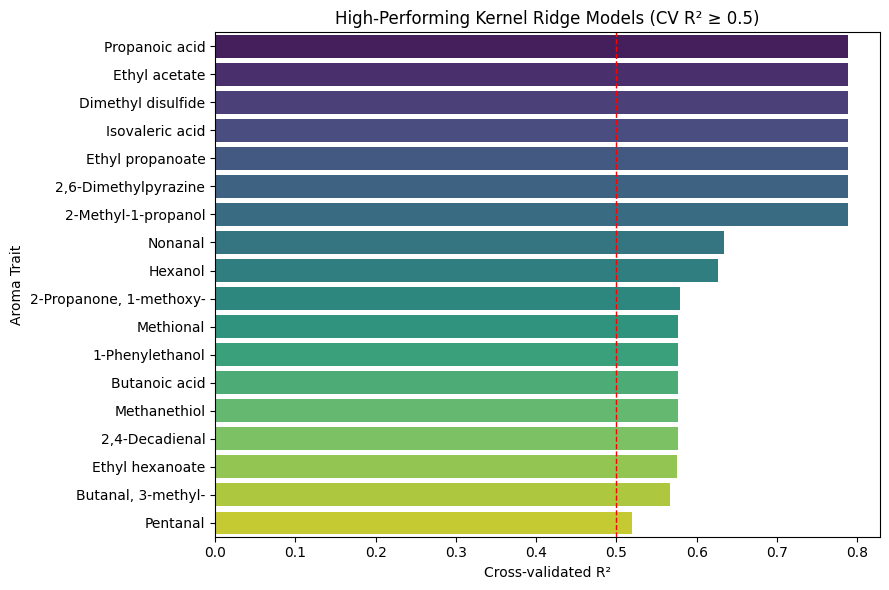

In [27]:
# Save list of high-predictive compounds
high_perf_path = r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Documents\GitHub\internship\high_predicted_aroma_traits.csv"
high_perf.to_csv(high_perf_path, index=False)
print(f" Saved high-performing compounds to: {high_perf_path}")

# Plot only these high-predicted compounds
plt.figure(figsize=(9, 6))
sns.barplot(
    data=high_perf.sort_values("CV_Best_R2", ascending=False),
    x="CV_Best_R2", y="Trait", palette="viridis"
)
plt.axvline(0.5, color="red", linestyle="--", lw=1)
plt.xlabel("Cross-validated R²")
plt.ylabel("Aroma Trait")
plt.title("High-Performing Kernel Ridge Models (CV R² ≥ 0.5)")
plt.tight_layout()
plt.show()


In [28]:
high_r2_traits = results_df.loc[results_df["CV_Best_R2"] >= 0.5, "Trait"].tolist()
X = predictions[high_r2_traits].copy()


In [29]:
import pandas as pd
import numpy as np

# --- Load projection (scores per variety)
projection_path = r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Documents\GitHub\internship\sensory_pca_projection.csv"
projection = pd.read_csv(projection_path)

# --- Load sensory PCA loadings (traits vs PCs)
loadings_path = r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Documents\GitHub\internship\sensory_pca_loadings.csv"
loadings = pd.read_csv(loadings_path, index_col=0)

# --- Extract PCA columns from projection (PC1–PC3)
X_scores = projection[["PC1", "PC2", "PC3"]].values
load_mat = loadings[["PC1", "PC2", "PC3"]].values

# --- Reconstruct sensory trait values
# multiply scores (variety × PC) by loadings.T (PC × traits)
sensory_reconstructed = np.dot(X_scores, load_mat.T)

# --- Create DataFrame with proper names
sensory_reconstructed_df = pd.DataFrame(
    sensory_reconstructed,
    index=projection["Variety"],
    columns=loadings.index
)

print(" Reconstructed sensory traits (per variety):")
display(sensory_reconstructed_df.head())

# --- Save to file
save_path = r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Documents\GitHub\internship\sensory_reconstructed_traits.csv"
sensory_reconstructed_df.to_csv(save_path)
print(f" Saved reconstructed sensory traits to: {save_path}")


 Reconstructed sensory traits (per variety):


,METALLIC FLAVOUR,BITTER FLAVOUR,EARTHY FLAVOUR,SOUR FLAVOUR,FRESH FLAVOUR,SWEET FLAVOUR,ROOT/ VEGETABLE FLAVOUR,FARMYARD (GRASS/HAY) FLAVOUR,BITTER AFTERTASTE,SOUR AFTERTASTE,SWEET AFTERTASTE,EARTHY AROMA,FARMYARD,SWEET,STARCHY,DAMP,BUTTERY,FRESH,POTATO STARCH,METALIC
Variety,,,,,,,,,,,,,,,,,,,,
ADORA,2.777227,3.021468,2.221376,2.850300,-1.066084,-0.847148,2.373826,2.495142,2.784747,3.016634,-1.006645,0.899148,1.878034,-0.157331,0.828773,1.786741,-0.069789,-0.149353,-0.225817,2.325663
AGRIA,-0.229637,-0.448615,0.509891,-0.827166,-0.731611,-1.171877,0.083648,0.310391,-0.388611,-1.042706,-1.130200,1.387898,-0.340720,-0.651435,1.694207,-0.093582,-0.849283,-1.680008,2.088016,0.320938
BERBER,-0.354242,-0.459819,0.098332,-0.640353,0.861787,0.459095,0.873152,0.428063,-0.596838,-0.754492,0.370748,-0.125063,-0.278329,1.418112,1.733750,-1.048533,1.192578,-0.023029,1.404938,-0.173067
BILDTSTAR,-0.143122,-0.293976,0.317844,-0.535582,-0.939388,-1.155316,-0.367521,0.003764,-0.178766,-0.677375,-1.078262,1.199855,-0.238350,-1.130382,0.698996,0.290940,-1.208747,-1.412395,1.204038,0.265307
BINTJE,-0.896907,-1.004481,-0.571348,-1.026723,0.614686,0.401464,-0.323025,-0.523106,-0.990835,-1.116110,0.412158,-0.289270,-0.621746,0.574778,0.430797,-0.885742,0.465161,0.026589,0.598025,-0.702797


 Saved reconstructed sensory traits to: C:\Users\fatemehm\OneDrive - Royal HZPC Group\Documents\GitHub\internship\sensory_reconstructed_traits.csv


✅ Common varieties found: 83
🧪 Using 18 high-predictive compounds for PLS
📈 Fitted PLS model with 5 components

🔗 Correlation between PLS components and sensory attributes:


,METALLIC FLAVOUR,BITTER FLAVOUR,EARTHY FLAVOUR,SOUR FLAVOUR,FRESH FLAVOUR,SWEET FLAVOUR,ROOT/ VEGETABLE FLAVOUR,FARMYARD (GRASS/HAY) FLAVOUR,BITTER AFTERTASTE,SOUR AFTERTASTE,SWEET AFTERTASTE,EARTHY AROMA,FARMYARD,SWEET,STARCHY,DAMP,BUTTERY,FRESH,POTATO STARCH,METALIC
PLS1,-0.02,0.02,-0.17,0.11,0.25,0.32,-0.01,-0.10,0.01,0.14,0.31,-0.34,0.05,0.23,-0.29,-0.08,0.27,0.38,-0.36,-0.14
PLS2,-0.09,-0.04,-0.24,0.04,0.23,0.30,-0.15,-0.21,-0.05,0.08,0.30,-0.34,-0.02,0.16,-0.38,-0.08,0.20,0.36,-0.39,-0.20
PLS3,0.34,0.36,0.23,0.38,-0.26,-0.17,0.11,0.20,0.37,0.38,-0.17,0.12,0.36,-0.25,-0.18,0.40,-0.21,-0.02,-0.21,0.29
PLS4,-0.13,-0.15,-0.10,-0.15,-0.17,-0.16,-0.33,-0.21,-0.11,-0.15,-0.13,0.12,-0.16,-0.29,-0.14,0.07,-0.29,-0.17,0.01,-0.08
PLS5,0.06,0.06,0.01,0.08,-0.11,-0.06,-0.10,-0.03,0.08,0.09,-0.06,0.03,0.06,-0.16,-0.16,0.14,-0.14,-0.01,-0.13,0.04


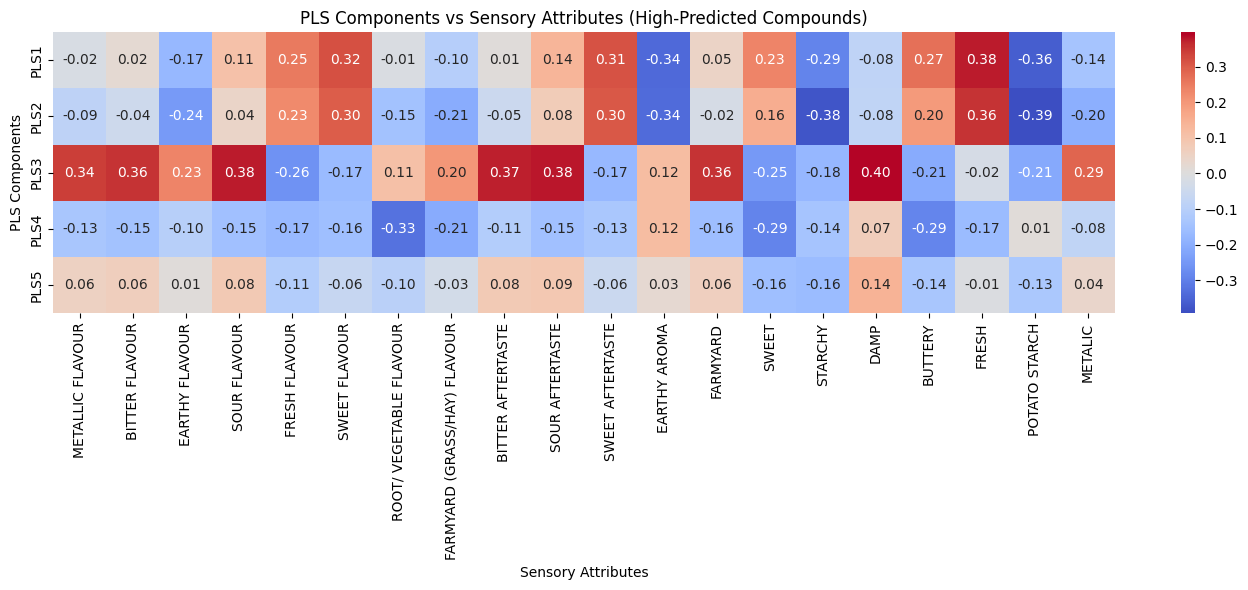

C:\Users\fatemehm\AppData\Local\Temp\ipykernel_8976\3163008268.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


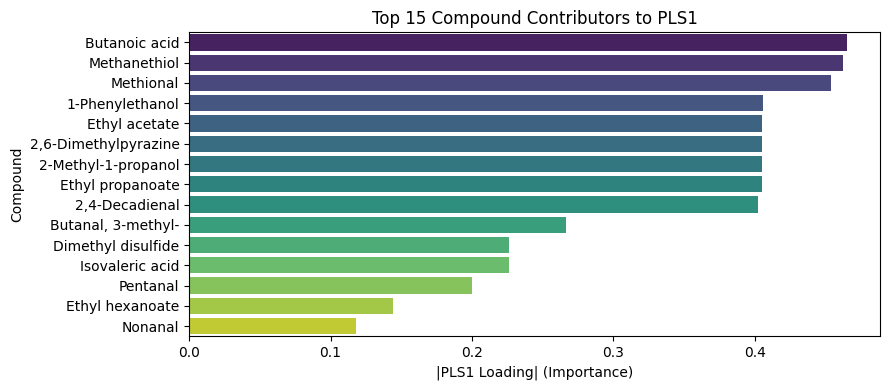

C:\Users\fatemehm\AppData\Local\Temp\ipykernel_8976\3163008268.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


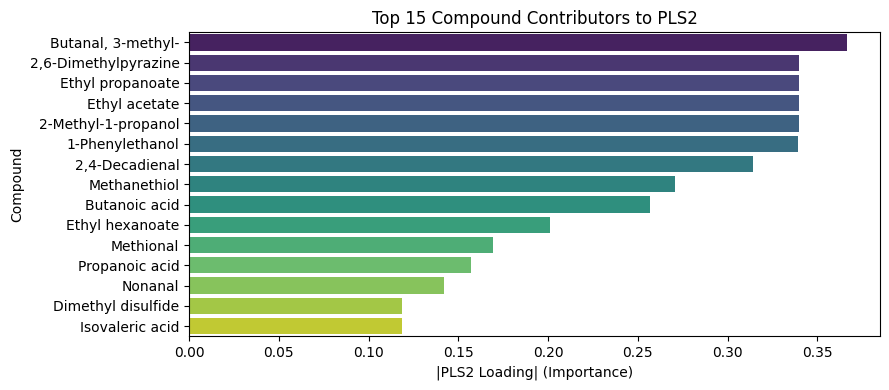

C:\Users\fatemehm\AppData\Local\Temp\ipykernel_8976\3163008268.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


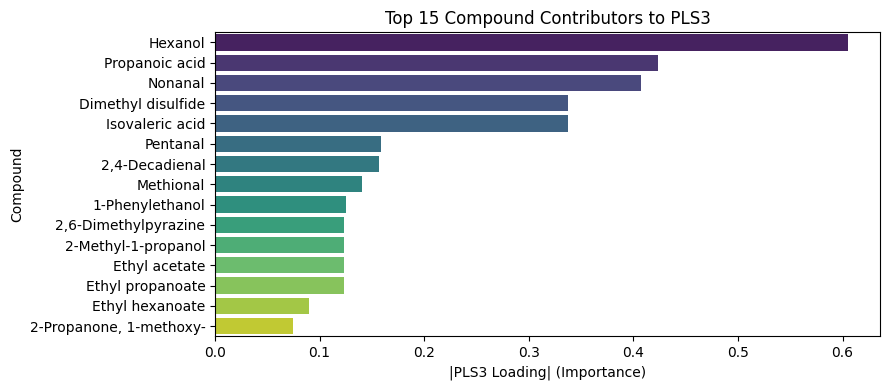

C:\Users\fatemehm\AppData\Local\Temp\ipykernel_8976\3163008268.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


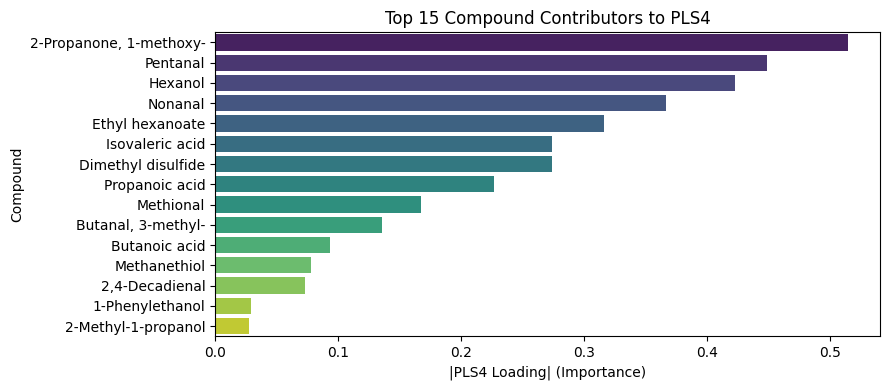

C:\Users\fatemehm\AppData\Local\Temp\ipykernel_8976\3163008268.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


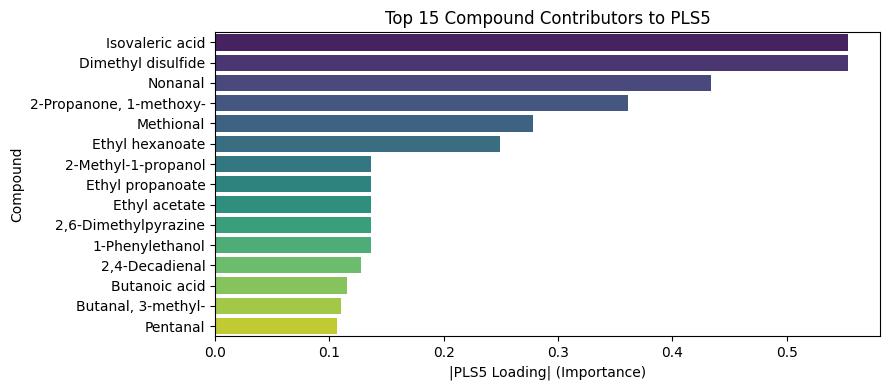


🍇 Flavor alignment per PLS axis:
  PLS1: aligned with FRESH (positive)
  PLS2: aligned with POTATO STARCH (negative)
  PLS3: aligned with DAMP (positive)
  PLS4: aligned with ROOT/ VEGETABLE FLAVOUR (negative)
  PLS5: aligned with STARCHY (negative)

💾 Correlation and loadings files saved successfully.


In [30]:
# ==========================================================
#  PLSR between High-Predictive Gene-Based Compounds and Sensory Attributes
# ==========================================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import StandardScaler

# ----------------------------------------------------------
# 1️⃣ Load reconstructed sensory traits (per variety)
# ----------------------------------------------------------
sensory_reconstructed_path = (
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Documents\GitHub\internship\sensory_reconstructed_traits.csv"
)
sensory_reconstructed_df = pd.read_csv(sensory_reconstructed_path, index_col=0)

# ----------------------------------------------------------
# 2️⃣ Align with high-predictive compounds (from KRR R² ≥ 0.5)
# ----------------------------------------------------------
# Normalize names for proper alignment
sensory_reconstructed_df.index = sensory_reconstructed_df.index.str.upper().str.replace(" ", "")
predictions.index = predictions.index.str.upper().str.replace(" ", "")

common_varieties = predictions.index.intersection(sensory_reconstructed_df.index)
print(f"✅ Common varieties found: {len(common_varieties)}")

# Keep only highly predictive compounds
X = predictions.loc[common_varieties, high_r2_traits]
Y = sensory_reconstructed_df.loc[common_varieties]

# Keep numeric only
X = X.select_dtypes(include=[np.number])
Y = Y.select_dtypes(include=[np.number])

print(f"🧪 Using {X.shape[1]} high-predictive compounds for PLS")

# ----------------------------------------------------------
# 3️⃣ Standardize both datasets
# ----------------------------------------------------------
X_scaled = StandardScaler().fit_transform(X)
Y_scaled = StandardScaler().fit_transform(Y)

# ----------------------------------------------------------
# 4️⃣ Fit PLS model
# ----------------------------------------------------------
n_components = min(5, X_scaled.shape[1], Y_scaled.shape[1])
pls = PLSRegression(n_components=n_components)
pls.fit(X_scaled, Y_scaled)
print(f"📈 Fitted PLS model with {n_components} components")

# ----------------------------------------------------------
# 5️⃣ Compute correlation between PLS components and sensory traits
# ----------------------------------------------------------
corr_df = pd.DataFrame(
    np.corrcoef(pls.x_scores_.T, Y_scaled.T)[:n_components, n_components:],
    index=[f"PLS{i+1}" for i in range(n_components)],
    columns=Y.columns,
)
print("\n🔗 Correlation between PLS components and sensory attributes:")
display(corr_df.round(2))

# ----------------------------------------------------------
# 6️⃣ Visualize heatmap of correlations
# ----------------------------------------------------------
plt.figure(figsize=(14, 6))
sns.heatmap(corr_df, cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("PLS Components vs Sensory Attributes (High-Predicted Compounds)")
plt.xlabel("Sensory Attributes")
plt.ylabel("PLS Components")
plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# 7️⃣ Compound loadings (importance per component)
# ----------------------------------------------------------
loadings_df = pd.DataFrame(
    pls.x_loadings_,
    index=X.columns,
    columns=[f"PLS{i+1}" for i in range(n_components)],
)

# Plot top 15 contributors per PLS axis
for comp in loadings_df.columns:
    top_loadings = loadings_df[comp].abs().sort_values(ascending=False).head(15)
    plt.figure(figsize=(9, 4))
    sns.barplot(
        x=top_loadings.values,
        y=top_loadings.index,
        palette="viridis"
    )
    plt.title(f"Top 15 Compound Contributors to {comp}")
    plt.xlabel(f"|{comp} Loading| (Importance)")
    plt.ylabel("Compound")
    plt.tight_layout()
    plt.show()

# ----------------------------------------------------------
# 8️⃣ Identify main sensory direction of each PLS axis
# ----------------------------------------------------------
flavor_alignment = {}
for comp in corr_df.index:
    best_match = corr_df.loc[comp].abs().idxmax()
    direction = "positive" if corr_df.loc[comp, best_match] > 0 else "negative"
    flavor_alignment[comp] = f"{best_match} ({direction})"

print("\n🍇 Flavor alignment per PLS axis:")
for comp, desc in flavor_alignment.items():
    print(f"  {comp}: aligned with {desc}")

# ----------------------------------------------------------
# 9️⃣ Save outputs
# ----------------------------------------------------------
corr_path = (
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Documents\GitHub\internship\pls_high_predicted_compound_sensory_correlations.csv"
)
loadings_path = (
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Documents\GitHub\internship\pls_high_predicted_compound_loadings.csv"
)
corr_df.to_csv(corr_path)
loadings_df.to_csv(loadings_path)

print("\n💾 Correlation and loadings files saved successfully.")


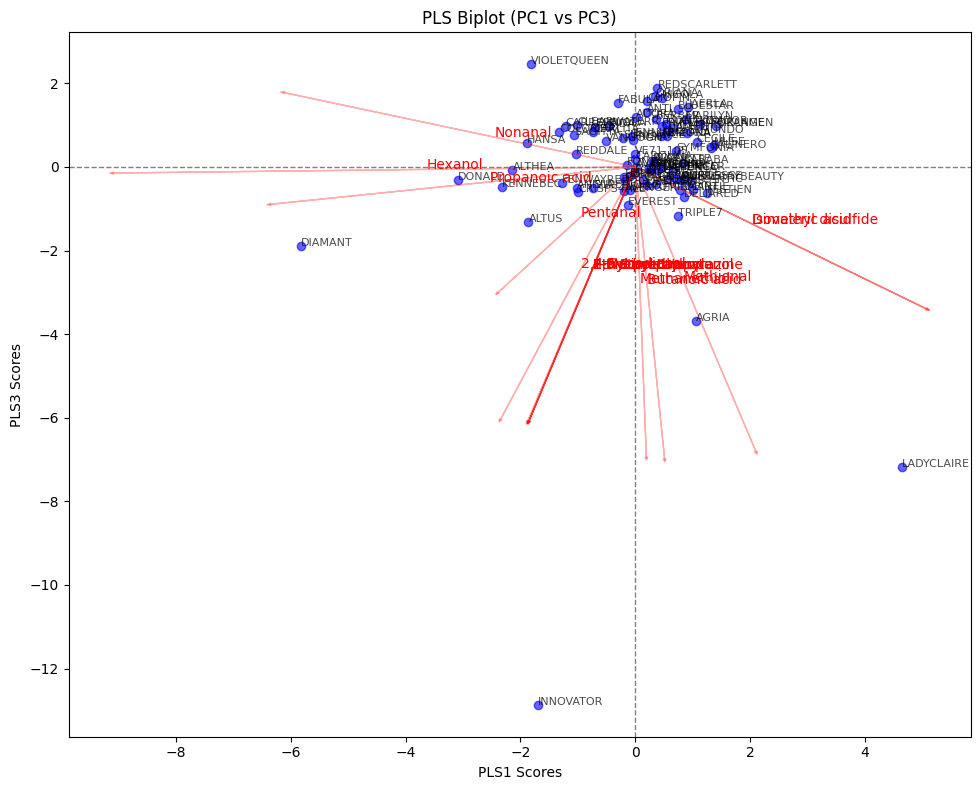

In [40]:
def pls_biplot(pls_model, X_scaled, Y_scaled, pc1=1, pc2=3, top_n_loadings=15, rotate='none'):
    """
    Biplot of PLS scores and top contributing loadings.
    rotate: 'none', '180', '90cw', '90ccw'
    """
    # Scores
    x_scores = pls_model.x_scores_[:, pc1-1]
    y_scores = pls_model.x_scores_[:, pc2-1]
    
    # 🔸 rotation options
    if rotate == '180':
        x_scores, y_scores = -x_scores, -y_scores
    elif rotate == '90cw':      # clockwise
        x_scores, y_scores = y_scores, -x_scores
    elif rotate == '90ccw':     # counterclockwise
        x_scores, y_scores = -y_scores, x_scores
    
    plt.figure(figsize=(10, 8))
    plt.scatter(x_scores, y_scores, c='blue', alpha=0.6, label='Varieties')
    
    for i, txt in enumerate(X.index):
        plt.text(x_scores[i], y_scores[i], txt, fontsize=8, alpha=0.7)
    
    # Loadings
    x_loadings = pls_model.x_loadings_[:, pc1-1]
    y_loadings = pls_model.x_loadings_[:, pc2-1]
    
    if rotate == '180':
        x_loadings, y_loadings = -x_loadings, -y_loadings
    elif rotate == '90cw':
        x_loadings, y_loadings = y_loadings, -x_loadings
    elif rotate == '90ccw':
        x_loadings, y_loadings = -y_loadings, x_loadings
    
    loadings_df = pd.DataFrame({'x': x_loadings, 'y': y_loadings}, index=X.columns)
    
    top_loadings = loadings_df.abs().sum(axis=1).sort_values(ascending=False).head(top_n_loadings).index
    for compound in top_loadings:
        plt.arrow(0, 0, loadings_df.loc[compound, 'x']*15, loadings_df.loc[compound, 'y']*15,
                  color='red', alpha=0.3, head_width=0.05)
        plt.text(loadings_df.loc[compound, 'x']*6, loadings_df.loc[compound, 'y']*6,
                 compound, color='red', fontsize=10)
    
    plt.axhline(0, color='grey', linestyle='--', linewidth=1)
    plt.axvline(0, color='grey', linestyle='--', linewidth=1)
    plt.xlabel(f"PLS{pc1} Scores")
    plt.ylabel(f"PLS{pc2} Scores")
    plt.title(f"PLS Biplot (PC{pc1} vs PC{pc2})")
    plt.grid(False)
    plt.tight_layout()
    plt.show()
pls_biplot(pls, 
           X_scaled=pd.DataFrame(X_scaled, index=X.index), 
           Y_scaled=pd.DataFrame(Y_scaled, index=Y.index),
           rotate='90ccw')


In [32]:
# ----------------------------------------------------------
# ✅ Compute cross-correlation matrix: Compounds × Sensory PCs
# ----------------------------------------------------------

# Ensure numeric-only data
merged_numeric = merged_corr_df.select_dtypes(include=[np.number])

# Identify overlap between prediction and sensory columns
pred_cols = [c for c in predictions.columns if c in merged_numeric.columns]
sens_cols = [c for c in sensory_pcs.columns if c in merged_numeric.columns]

# Extract the two numeric blocks
X_pred = merged_numeric[pred_cols].to_numpy()
X_sens = merged_numeric[sens_cols].to_numpy()

# Compute correlation manually for cross-matrix
corr_matrix = np.corrcoef(X_pred.T, X_sens.T)[:len(pred_cols), len(pred_cols):]

# Convert to DataFrame
corr_matrix = pd.DataFrame(corr_matrix, index=pred_cols, columns=sens_cols)

print("✅ Correlation matrix shape:", corr_matrix.shape)
display(corr_matrix.head())


✅ Correlation matrix shape: (18, 3)


,PC1,PC2,PC3
1-Phenylethanol,0.037417,-0.087677,-0.077835
"2,4-Decadienal",0.041658,-0.075663,-0.068339
"2,6-Dimethylpyrazine",0.037176,-0.088051,-0.078117
2-Methyl-1-propanol,0.037176,-0.088051,-0.078117
"2-Propanone, 1-methoxy-",0.027836,0.041030,0.091441


Top 5 gene-predicted compounds most related to sensory PCs:


Butanal, 3-methyl-    0.239601
Nonanal               0.225115
Hexanol               0.188107
Ethyl hexanoate       0.148369
Propanoic acid        0.115144
dtype: float64


✅ Triangle relationships (top 5 compounds × top 10 SNPs each):


,Gene (SNP),Compound,Sensory PC,Compound–Sensory Corr
0,GEN__33327,"Butanal, 3-methyl-",PC2,0.372569
1,GEN__315464,"Butanal, 3-methyl-",PC2,0.372569
2,GEN__34365,"Butanal, 3-methyl-",PC2,0.372569
3,GEN__34432,"Butanal, 3-methyl-",PC2,0.372569
4,GEN__34396,"Butanal, 3-methyl-",PC2,0.372569
5,GEN__34473,"Butanal, 3-methyl-",PC2,0.372569
6,GEN__34513,"Butanal, 3-methyl-",PC2,0.372569
7,GEN__421498,"Butanal, 3-methyl-",PC2,0.372569
8,GEN__388405,"Butanal, 3-methyl-",PC2,0.372569
9,GEN__388447,"Butanal, 3-methyl-",PC2,0.372569


Triangle table saved as 'gene_compound_sensory_triangle.csv'


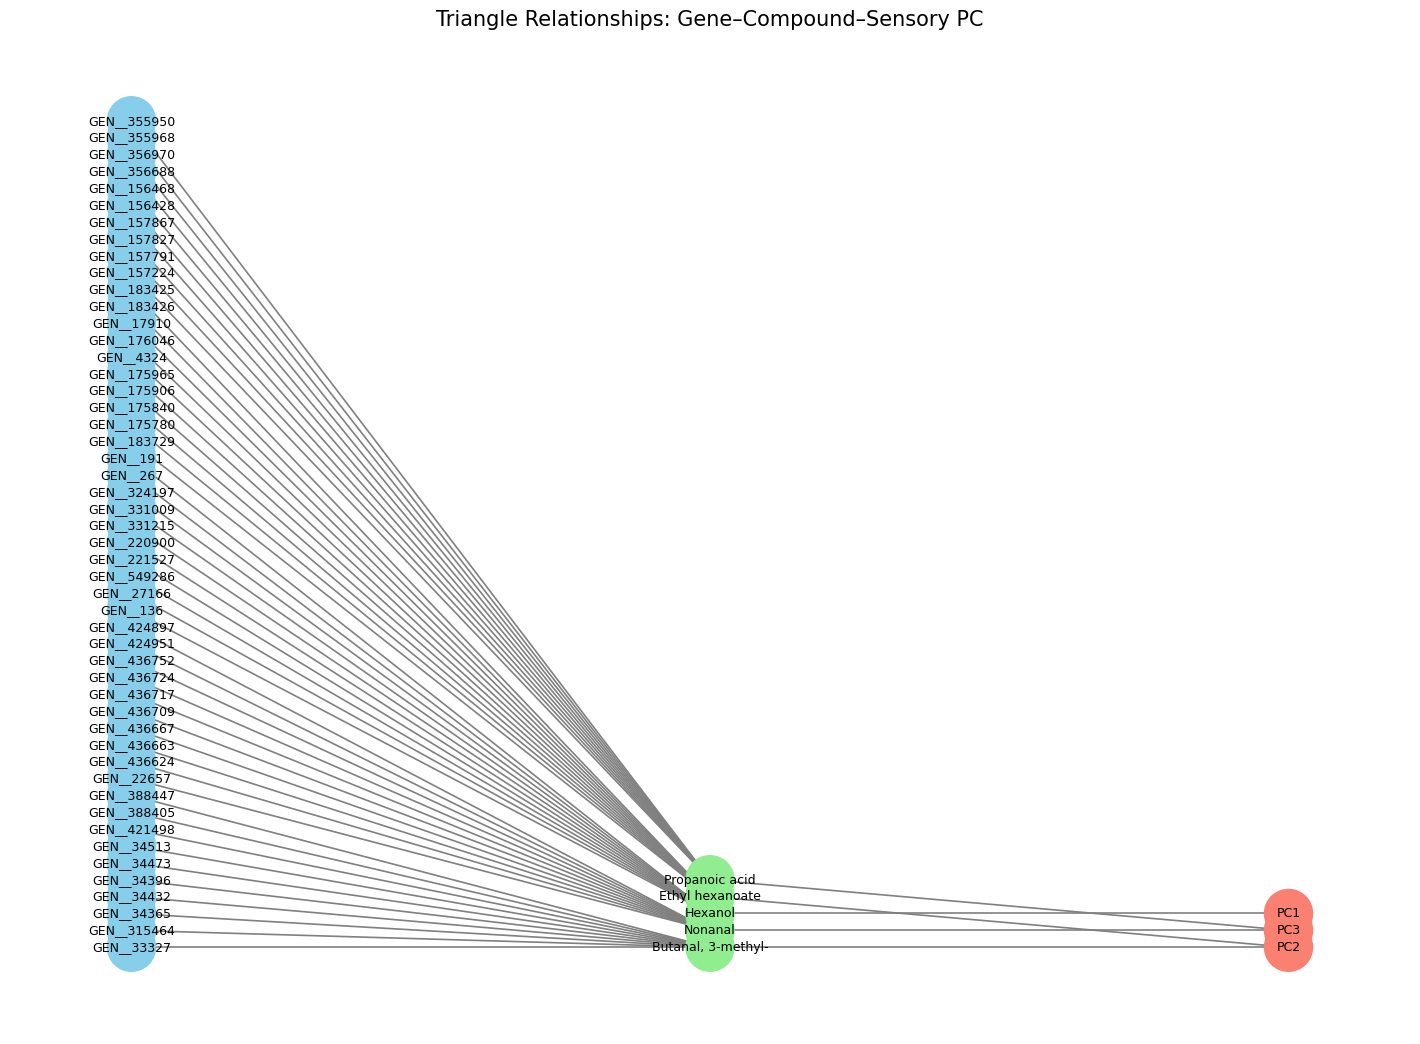

In [ ]:
# ==========================================================
# 🔺 Build Gene–Compound–Sensory PC Triangle
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

# ----------------------------------------------------------
# Extract top 5 compounds most correlated with sensory PCs
# ----------------------------------------------------------
top_compounds = corr.abs().mean(axis=1).sort_values(ascending=False)
top_traits = top_compounds.head(5).index.tolist()

print("Top 5 gene-predicted compounds most related to sensory PCs:")
display(top_compounds.head(5))

# ----------------------------------------------------------
# Build triangle relationships: Gene → Compound → Sensory PC
# ----------------------------------------------------------
triangle_links = []

for compound in top_traits:
    # Step 1: find the sensory PC most correlated with this compound
    sensory_target = corr_matrix.loc[compound].abs().idxmax()
    corr_value = corr_matrix.loc[compound, sensory_target]

    # Step 2: get the top associated genes (SNPs) for this compound
    top_genes = (
        gwas_all[gwas_all["Trait"] == compound]
        .sort_values("p_fdr")
        .head(10)["SNP"]
        .tolist()
    )

    # Step 3: store the links
    for gene in top_genes:
        triangle_links.append({
            "Gene (SNP)": gene,
            "Compound": compound,
            "Sensory PC": sensory_target,
            "Compound–Sensory Corr": corr_value
        })

triangle_df = pd.DataFrame(triangle_links)
print("\n✅ Triangle relationships (top 5 compounds × top 10 SNPs each):")
display(triangle_df.head(20))

# Save results
triangle_df.to_csv("gene_compound_sensory_triangle.csv", index=False)
print("Triangle table saved as 'gene_compound_sensory_triangle.csv'")

# ----------------------------------------------------------
# 🔺 Visualization — Network Graph (Triangle Layout)
# ----------------------------------------------------------

# Create the network graph
G = nx.Graph()

# Add nodes and edges
for _, row in triangle_df.iterrows():
    G.add_node(row["Gene (SNP)"], color="skyblue", layer="Gene")
    G.add_node(row["Compound"], color="lightgreen", layer="Compound")
    G.add_node(row["Sensory PC"], color="salmon", layer="Sensory")

    G.add_edge(row["Gene (SNP)"], row["Compound"], weight=0.8)
    G.add_edge(row["Compound"], row["Sensory PC"], weight=abs(row["Compound–Sensory Corr"]))

# Create a layered layout (Genes left, Compounds center, Sensory right)
pos = {}
x_gene, x_comp, x_sens = 0, 1, 2
y_gap = 1.0

genes = [n for n, d in G.nodes(data=True) if d["layer"] == "Gene"]
comps = [n for n, d in G.nodes(data=True) if d["layer"] == "Compound"]
senses = [n for n, d in G.nodes(data=True) if d["layer"] == "Sensory"]

for i, g in enumerate(genes):
    pos[g] = (x_gene, i * y_gap)
for i, c in enumerate(comps):
    pos[c] = (x_comp, i * y_gap)
for i, s in enumerate(senses):
    pos[s] = (x_sens, i * y_gap)

# Draw network
node_colors = [G.nodes[n].get("color") for n in G.nodes]

plt.figure(figsize=(14, 10))
nx.draw(
    G, pos,
    with_labels=True,
    node_color=node_colors,
    node_size=1200,
    font_size=9,
    edge_color="gray",
    width=1.2
)
plt.title("Triangle Relationships: Gene–Compound–Sensory PC", fontsize=15)
plt.axis("off")
plt.show()
